**Code by: Blaine Smith AND Farib Sadman Haque**

# **Section 1**
## Extracting and gathering data


---

In [ ]:
pip install pdfplumber

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 101.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 96.8 MB/s eta 0:00:00


## **Section 1.1.1**

Collecting SSVF Award data from annual reports/ From tables

In [ ]:
# This is the code that collects all of the data for 2016,2017, and 2022
# It works, and all the data is there, I just have to clean it all up, which is a process I already did earlier for 2022
import pdfplumber
import pandas as pd

def process_ssvf_pdf(pdf_path, year, title_row_present=True):
    """
    Process a single SSVF PDF and return a cleaned DataFrame.

    Args:
        pdf_path (str): Path to the PDF file.
        year (int): Fiscal year of the PDF.
        title_row_present (bool): True if the PDF has a title row before headers (like 2016, 2017).

    Returns:
        dict: {'Year': year, 'Data': cleaned DataFrame}
    """
    all_rows = []
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            table = page.extract_table()
            if table:
                all_rows.extend(table)

    # Determine header and data start row
    header_index = 1 if title_row_present else 0
    data_index = header_index + 1

    header = all_rows[header_index]
    data = all_rows[data_index:]

    # Replace None in header and ensure uniqueness
    header = [str(h).strip() if h is not None else f"col_{i}" for i, h in enumerate(header)]
    df = pd.DataFrame(data, columns=header)

    # Standardize column names
    rename_map = {
        'Organization': 'Grantee Name',
        'Award Amount': 'Award Amount',
        'CoCs to be Served': 'CoC Codes',
        'CoC Codes': 'CoC Codes',  # in case 2022-style
    }
    df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns}, inplace=True)

    # Clean Award Amount
    if 'Award Amount' in df.columns:
        df['Award Amount'] = pd.to_numeric(
            df['Award Amount'].str.replace('[\$,]', '', regex=True),
            errors='coerce'
        ).fillna(0)
    else:
        df['Award Amount'] = 0

    # Clean CoC Codes
    if 'CoC Codes' in df.columns:
        df['CoC Codes'] = df['CoC Codes'].astype(str).str.replace('[\(\)]', '', regex=True).str.strip().str.upper()
        df['CoC Codes'] = df['CoC Codes'].str.split(',').explode('CoC Codes').reset_index(drop=True)
        df['CoC Codes'] = df['CoC Codes'].str.strip()
    else:
        df['CoC Codes'] = None

    # Fractional allocation
    if 'Grantee Name' in df.columns:
        df['Num_CoCs'] = df.groupby('Grantee Name')['CoC Codes'].transform('count')
        df['Award Fraction'] = df['Award Amount'] / df['Num_CoCs']
    else:
        df['Num_CoCs'] = 1
        df['Award Fraction'] = df['Award Amount']

    return {'Year': year, 'Data': df}

def process_multiple_ssvf_pdfs(pdf_dict):
    """
    Process multiple SSVF PDFs and return a list of dictionaries.

    Args:
        pdf_dict (dict): {year: pdf_path}

    Returns:
        list: [{'Year': year, 'Data': DataFrame}, ...]
    """
    ssvf_list_of_dicts = []
    for year, path in pdf_dict.items():
        # Determine if title row is present (2016 need True)
        title_row_present = year in [2016]
        print(f"Processing {year} from {path}...")
        ssvf_list_of_dicts.append(process_ssvf_pdf(path, year, title_row_present))
    return ssvf_list_of_dicts

<>:48: SyntaxWarning: invalid escape sequence '\$'
<>:56: SyntaxWarning: invalid escape sequence '\('
<>:48: SyntaxWarning: invalid escape sequence '\$'
<>:56: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_750/1242413253.py:48: SyntaxWarning: invalid escape sequence '\$'
  df['Award Amount'].str.replace('[\$,]', '', regex=True),
/tmp/ipykernel_750/1242413253.py:56: SyntaxWarning: invalid escape sequence '\('
  df['CoC Codes'] = df['CoC Codes'].astype(str).str.replace('[\(\)]', '', regex=True).str.strip().str.upper()


In [ ]:
pdf_dict = {
    2016: "SSVF_FY2016_Grant_Awards.pdf",
    #2017: "SSVF_FY2017_Grant_Awards.pdf",
    2022: "SSVF_FY2022_Grant_Awards.pdf"
}
ssvf_list_of_dicts = process_multiple_ssvf_pdfs(pdf_dict)

# Quick look
print(ssvf_list_of_dicts[0]['Year'])      # '2016'
print(ssvf_list_of_dicts[0]['Data'].head())

Processing 2016 from SSVF_FY2016_Grant_Awards.pdf...
Processing 2022 from SSVF_FY2022_Grant_Awards.pdf...
2016
  State(s) Served    Award #                                 Grantee Name  \
0              AK  12-AK-001                     Catholic Social Services   
1              AL  12-AL-002                          Housing First, Inc.   
2              AZ  12-AZ-003        United Methodist Outreach\nMinistries   
3              AZ  12-AZ-004                         Primavera Foundation   
4              CA  12-CA-006  Volunteers of America of Los\nAngeles, Inc.   

                 Counties to be Served CoC Codes  Award Amount  Num_CoCs  \
0         Anchorage, Matanuska-Susitna    AK-500      536641.0       1.0   
1  Mobile, Baldwin, Washington, Clarke    AK-501     1327000.0       1.0   
2                      Maricopa County    AL-501      728749.0       1.0   
3                          Pima County    AL-507     1071011.0       1.0   
4                          Los Angeles    AZ-5

In [ ]:
# Looking at each year: 2016, 2017, 2022
# I just wanna look at each year
print(ssvf_list_of_dicts[0]['Year'])      # '2016'
ssvf_list_of_dicts[0]['Data'].head()

2016


,State(s) Served,Award #,Grantee Name,Counties to be Served,CoC Codes,Award Amount,Num_CoCs,Award Fraction
0,AK,12-AK-001,Catholic Social Services,"Anchorage, Matanuska-Susitna",AK-500,536641.0,1.0,536641.0
1,AL,12-AL-002,"Housing First, Inc.","Mobile, Baldwin, Washington, Clarke",AK-501,1327000.0,1.0,1327000.0
2,AZ,12-AZ-003,United Methodist Outreach\nMinistries,Maricopa County,AL-501,728749.0,1.0,728749.0
3,AZ,12-AZ-004,Primavera Foundation,Pima County,AL-507,1071011.0,1.0,1071011.0
4,CA,12-CA-006,"Volunteers of America of Los\nAngeles, Inc.",Los Angeles,AZ-502,2000000.0,2.0,1000000.0


In [ ]:
print(ssvf_list_of_dicts[1]['Year'])      # '2017'
ssvf_list_of_dicts[1]['Data'].head()

In [ ]:
print(ssvf_list_of_dicts[2]['Year'])      # '2022'
ssvf_list_of_dicts[2]['Data'].head()

In [ ]:
# We can see here that we have made a lot of progress, I just need to clean things up a bit to get it
# Seperated into the SSVF Award amount per state. It will be more of a manual cleanup

In [ ]:
#Imma just use a function for each of the years
import pandas as pd
import numpy as np

# Get your DataFrames
df2016 = ssvf_list_of_dicts[0]['Data']
# df2017 = ssvf_list_of_dicts[1]['Data'] #Using 2017 later
df2022 = ssvf_list_of_dicts[1]['Data']
# Drop rows where 'Grant Award\nAmount' literally equals the column name
df2022 = df2022[df2022['Grant Award\nAmount'] != 'Grant Award\nAmount']

# Now safely convert to numeric
df2022['Grant Award\nAmount'] = (
    df2022['Grant Award\nAmount']
    .str.replace('[\$,]', '', regex=True)
    .astype(float)
)

def clean_2016(df):
    df = df.rename(columns={
        'Award #': 'Award No.',
        'Counties to be Served': 'Counties Served',
        'State(s) Served': 'State',
    })
    df['Year'] = 2016
    df['Award No.'] = df['Award No.'].str.strip()
    df['Grantee Name'] = df['Grantee Name'].str.replace('\n', ' ', regex=False)
    return df[['Year', 'Award No.', 'Grantee Name', 'State', 'Award Amount', 'Num_CoCs']]

def clean_2017(df):
    df = df.rename(columns={
        'Award\nNumber': 'Award No.',
        'Organization Name': 'Grantee Name',
        'State(s)\nServed': 'State',
        'Counties to be Served': 'Counties Served',
    })
    df['Year'] = 2017
    # Clean up line breaks and text
    df['Grantee Name'] = df['Grantee Name'].str.replace('\n', ' ', regex=False)
    df['CoC Codes'] = df['CoC Codes'].str.replace('\n', ' ', regex=False).str.strip()
    return df[['Year', 'Award No.', 'Grantee Name', 'State', 'Award Amount', 'Num_CoCs']]

def clean_2022(df):

    # --- Drop the duplicate zero-filled column if it exists ---
    if 'Award Amount' in df.columns:
        df = df.drop(columns=['Award Amount'])

    # --- Rename the original Grant Award column ---
    df = df.rename(columns={
        'Grant\nAward No.': 'Award No.',
        'Organization Name': 'Grantee Name',
        'Grant Award\nAmount': 'Award Amount'
    })

    df['Year'] = 2022
    df = df[df['Award Amount'] != 'Award Amount']
    # --- Clean Award Amount from the original column ---
    df['Award Amount'] = (
        df['Award Amount']
        .astype(str)
        .str.replace('[\$,]', '', regex=True)
        .str.replace(',', '', regex=False)   # remove thousands separator
        .astype(float)
    )

    # --- Clean Grantee Name ---
    df['Grantee Name'] = df['Grantee Name'].astype(str).str.replace('\n', ' ', regex=False)

    # --- Extract State from Award No ---
    df['State'] = df['Award No.'].astype(str).str.extract(r'-(\w{2})-')

    # --- Fill missing Num_CoCs if needed ---
    if 'Num_CoCs' not in df.columns:
        df['Num_CoCs'] = 1

    return df[['Year', 'Award No.', 'Grantee Name', 'State', 'Award Amount', 'Num_CoCs']]

<>:15: SyntaxWarning: invalid escape sequence '\$'
<>:62: SyntaxWarning: invalid escape sequence '\$'
<>:15: SyntaxWarning: invalid escape sequence '\$'
<>:62: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_750/1725179320.py:15: SyntaxWarning: invalid escape sequence '\$'
  .str.replace('[\$,]', '', regex=True)
/tmp/ipykernel_750/1725179320.py:62: SyntaxWarning: invalid escape sequence '\$'
  .str.replace('[\$,]', '', regex=True)
/tmp/ipykernel_750/1725179320.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2022['Grant Award\nAmount'] = (


In [ ]:
# Apply cleaning
cleaned_2016 = clean_2016(df2016)
#cleaned_2017 = clean_2017(df2017) Using 2017 later
cleaned_2022 = clean_2022(df2022)
# So freaking close, I was struggling with getting the award amount correct for 2022
# Now I just have some extra rows that need to get dropped. For now. I am going to drop all rows
# with ZZ in Award No. as I do not feel like dealing with awards split between States right now

In [ ]:
# I can eventually move this to the main clean function im sure
# However, I finally managed to get that function to work and I do not want to potentialy  mess it up


def extra_clean(df):
  # Drop rows where 'Award No.' contains 'ZZ'
  # the actual reason I am doing this is beacuse for some years, I do actually have
  # what states are a part of the split. However, even among these, they dont have the exact split
  # This part of the function I beleive fixes 2022
  df = df[~df['Award No.'].str.contains('ZZ', na=False)]

  #This will be getting rid of the rows where a header was input as a row, necessary for 2017 and 2016
  # Any row that has "Award" in it will go away
  df = df[~df['Award No.'].astype(str).str.contains('Award', na=False, case=False)]

  #So technically, there are some more rows that have some funky "Award No.", but I just
  # Remebered that if they are just a bit messed up, all I need is the State and Award Amount
  # Some examples are S20-WA-\n500, and 12-FL-025(cid:9)(cid:9)(cid:9)(cid:9).
  # The format is wrong, but the State and Award Amount are good to go

  #There are still some rows that have no information, so we need to remove those
  # Only needto do this for 2016 and 2022 so imma just do it outside the function

  return df


In [ ]:
cleaned_2016 = extra_clean(cleaned_2016)
#cleaned_2017 = extra_clean(cleaned_2017) using 2017 later
cleaned_2022 = extra_clean(cleaned_2022)


In [ ]:
#Getting rid of the last row for 2016 and 2022.
# I can defintly put this into a function later for organization purposes
cleaned_2016 = cleaned_2016.iloc[:-1]
cleaned_2022 = cleaned_2022.iloc[:-1]

In [ ]:
cleaned_2022.tail()

In [ ]:
# Okay, each of the years have been cleaned enough for the next step. Now I can get the total
# Award amount per state, per year. It has been awhile, so I think it is okay
# If I have it in a dataframe format, but I know for some situations I used dictionaries to hold each year

#This function puts things into a dataframe and collects the amount of award money per state
def summarize_by_state(df):
    """
    Summarize total award amount by state.

    Args:
        df (pd.DataFrame): Cleaned SSVF DataFrame with 'State' and 'Award Amount'

    Returns:
        pd.DataFrame: Columns ['State', 'ssvf_award_total'], sorted by State
    """
    df = df[~df['State'].str.contains(',', na=False)] #I am not dealing with multiple state grants rn
    # The line above gets rid of all grants in the format ST,ST
    summary = (
        df.groupby('State', as_index=False)['Award Amount']
          .sum()
          .rename(columns={'Award Amount': 'ssvf_award_total'})
          .sort_values('State')
          .reset_index(drop=True)
    )


    return summary


In [ ]:
#Simply calling the function
summary_2016 = summarize_by_state(cleaned_2016)
#summary_2017 = summarize_by_state(cleaned_2017) using 2017 later
summary_2022 = summarize_by_state(cleaned_2022)

In [ ]:
summary_2022.head(10)

,State,ssvf_award_total
0,AK,1399525.0
1,AL,1750984.0
2,AR,2159003.0
3,AZ,9509176.0
4,CA,78868070.0
5,CO,4415242.0
6,CT,3609826.0
7,DC,750000.0
8,FL,28878338.0
9,GA,6584450.0


In [ ]:
summary_2022.describe()

,ssvf_award_total
count,4.900000e+01
mean,6.942244e+06
std,1.198933e+07
min,3.160400e+05
25%,1.750984e+06
50%,3.996139e+06
75%,6.827304e+06
max,7.886807e+07


In [ ]:
summary_2022.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             49 non-null     object 
 1   ssvf_award_total  49 non-null     float64
dtypes: float64(1), object(1)
memory usage: 916.0+ bytes


In [ ]:
#I do believe it needs to be in a dictionary format, so here you go
# Create a list of dictionaries with summarized totals


#Keep this here for now. When looking at certian sections, this will be useful
# But when running the entire file, run the version of this in 1.1.3
# It emcompases all of the years that use the summarize_by_state function
ssvf_summary_list = [
    {'Year': 2016, 'Data': summarize_by_state(cleaned_2016)},
    {'Year': 2017, 'Data': summarize_by_state(cleaned_2017)},
    {'Year': 2022, 'Data': summarize_by_state(cleaned_2022)},
]


NameError: name 'cleaned_2017' is not defined

In [ ]:
print(ssvf_summary_list[0]['Year'])
print(ssvf_summary_list[0]['Data'].head())


## **Section 1.1.2**

Collecting SSVF Awards data from Annual Reports/ SSVF Reports

In [ ]:
#10/2/2025
#I asked chat to give me a function for the annual reports, I have not checked if this works, and
#I want to make it where I can just put in the path and get what I need
#With this function, you have to call it for each year
#10/4/2025
# I had to play with this for awhile to get through the multiple different formats of the reports
# Unfortunatly, it still does not work for 2012 because it doesn't have a state column
# There is a function underneath that lets me call the function for a list of years
# I am tired, so I cannot be asked to go through and comment everything right now

#10/25/2025
# This cell does need to be run, this function is used the the extract_multiple_ssvf_reports function

import pdfplumber
import pandas as pd
import re

def extract_ssvf_state_totals(pdf_path, year, fractional_allocation=True):
    """
    Extracts state-level SSVF award totals from an annual report PDF.

    Parameters:
        pdf_path (str): Path to the SSVF annual report PDF.
        year (int or str): Fiscal year, used to name the output column.
        fractional_allocation (bool): Whether to split multi-state awards fractionally.

    Returns:
        pd.DataFrame: DataFrame with columns ["State", f"ssvf_award_total_{year}"].
    """
    all_rows = []
    with pdfplumber.open(pdf_path) as pdf:
        for page_num, page in enumerate(pdf.pages, 1):
            table = page.extract_table()
            if not table:
                continue

            # Clean header row
            header = [str(h).strip() if h else "" for h in table[0]]
            header_text = " ".join(header).lower()

            # Accept table if it looks like a grantee/award table
            if any(k in header_text for k in ["state", "location", "grantee", "grant"]):
                data = table[1:]
                max_cols = max(len(r) for r in data)

                # Normalize header length
                if len(header) < max_cols:
                    header += [f"Extra_{i}" for i in range(max_cols - len(header))]
                elif len(header) > max_cols:
                    header = header[:max_cols]

                # Normalize data rows
                data = [r + [""] * (max_cols - len(r)) if len(r) < max_cols else r[:max_cols] for r in data]

                # Append full table
                all_rows.extend([header] + data)

    if not all_rows:
        print(f"⚠️ No usable tables found in {pdf_path}")
        return pd.DataFrame()

    # --- Construct DataFrame safely ---
    header = all_rows[0]
    data = all_rows[1:]

    # Normalize header length
    max_len = max(len(header), max(len(r) for r in data))
    header = (header + [f"Extra_{i}" for i in range(max_len - len(header))])[:max_len]
    normalized_data = [(r + [""] * (max_len - len(r)))[:max_len] for r in data]

    # Ensure unique header names (avoid duplicate column errors)
    header = [h if h and h.strip() else f"Unnamed_{i}" for i, h in enumerate(header)]
    seen = {}
    for i, h in enumerate(header):
        if h in seen:
            seen[h] += 1
            header[i] = f"{h}_{seen[h]}"
        else:
            seen[h] = 0

    df = pd.DataFrame(normalized_data, columns=header)

    # Clean column names
    df.columns = (
        df.columns.str.replace(r"\n", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    # Identify potential Award column
    award_col = next(
      (c for c in df.columns if re.search(
        r'(?i)(award|grant).*?(amount|total|\$|funds spent)', c)
      ),
      None
    )
    if not award_col:
        # fallback: look for numeric-looking column if everything else fails
        numeric_cols = [
            c for c in df.columns
            if df[c].astype(str).str.contains(r"[\d,]+\.\d+|\$\d").any()
        ]
        award_col = numeric_cols[0] if numeric_cols else None

    if not award_col:
        print(f"⚠️ No Award Amount column found in {pdf_path}")
        print(f"Detected columns: {list(df.columns)}")
        return pd.DataFrame()

    # --- Identify State column ---
    state_col = next(
        (c for c in df.columns if re.search(r'(?i)(state|location)', c)), None
    )

    # --- Identify Grant Number (used for multi-state awards) ---
    grant_no_col = next(
        (c for c in df.columns if re.search(r'(?i)grant.*(number|no)', c)), None
    )

    # Rename standard columns
    rename_map = {}
    if award_col: rename_map[award_col] = "Award Amount"
    if grant_no_col: rename_map[grant_no_col] = "Grant Award No."
    if state_col: rename_map[state_col] = "State"
    df.rename(columns=rename_map, inplace=True)

    # --- Clean numeric award values ---
    df["Award Amount"] = (
        df["Award Amount"]
        .astype(str)
        .str.replace("[\$,]", "", regex=True)
        .str.replace("—", "0")
        .str.replace("None", "0")
    )
    df["Award Amount"] = pd.to_numeric(df["Award Amount"], errors="coerce").fillna(0)


    # --- Clean state names if State column exists ---
    if "State" in df.columns and not fractional_allocation:
      df["State"] = df["State"].astype(str).str.strip()
      df = df[~df["State"].str.contains("Total", case=False, na=False)]
      df = df[df["State"] != "State"]


    # --- Fractional allocation for multi-state grants ---
    if fractional_allocation and "Grant Award No." in df.columns:
        df["Grant Award No."] = df["Grant Award No."].astype(str)
        df["State_List"] = df["Grant Award No."].str.findall(r"[A-Z]{2}")
        df["Num_States"] = df["State_List"].str.len().replace(0, 1)
        df = df.explode("State_List").reset_index(drop=True)
        df["Award Fraction"] = df["Award Amount"] / df["Num_States"]
        df_state_totals = (
            df.groupby("State_List", as_index=False)["Award Fraction"].sum()
            .rename(columns={"State_List": "State",
                             "Award Fraction": f"ssvf_award_total_{year}"})
        )
    else:
        df_state_totals = (
            df.groupby("State", as_index=False)["Award Amount"].sum()
            .rename(columns={"Award Amount": f"ssvf_award_total_{year}"})
        )

    return df_state_totals




<>:131: SyntaxWarning: invalid escape sequence '\$'
<>:131: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_750/2367668205.py:131: SyntaxWarning: invalid escape sequence '\$'
  .str.replace("[\$,]", "", regex=True)


In [ ]:
#This is the output of the above function
# This is just to make sure that it actually works
pdf_path_2014 = "SSVF_FY2014_Annual_Report_FINAL.pdf"
state_awards_2014 = extract_ssvf_state_totals(pdf_path_2014, 2014)
print(state_awards_2014.head())

KeyboardInterrupt: 

In [ ]:
#This function calls the function above to go through a list of years
# As of now those years are 2013-2015
def extract_multiple_ssvf_reports(pdf_dict, fractional_allocation=True):
    """
    Extract SSVF state-level totals from multiple annual report PDFs and combine them.

    Parameters:
        pdf_dict (dict): Dictionary mapping {year: pdf_path}
        fractional_allocation (bool): Whether to use fractional allocation for multi-state grants.

    Returns:
        pd.DataFrame: Combined DataFrame with one column per year.
    """
    all_dfs = []

    for year, path in pdf_dict.items():
        print(f"Processing {year} from {path}...")
        df_year = extract_ssvf_state_totals(path, year, fractional_allocation=fractional_allocation)
        if not df_year.empty:
            all_dfs.append(df_year)

    if not all_dfs:
        print("No valid data extracted.")
        return pd.DataFrame()

    # Merge all DataFrames on 'State'
    combined_df = all_dfs[0]
    for df in all_dfs[1:]:
        combined_df = pd.merge(combined_df, df, on="State", how="outer")

    # Sort states alphabetically for readability
    combined_df = combined_df.sort_values("State").reset_index(drop=True)

    return combined_df

In [ ]:
#For now, this onl works for certian formats, and 2012 does not follow that format
#Specfically, it has problems with the state column because it doesnt have one
#I would need to change the extract_ssvf_state_totals function
pdf_dict = {
    #These are found in the important links doc
    #2012: "SSVF_FY2012_Annual_Report_FINAL.pdf",
    2013: "SSVF_FY2013_Annual_Report_FINAL.pdf",
    2014: "SSVF_FY2014_Annual_Report_FINAL.pdf",
    2015: "SSVF_FY2015_Annual_Report_FINAL.pdf"

}

combined_awards = extract_multiple_ssvf_reports(pdf_dict)
print(combined_awards.head())

Processing 2013 from SSVF_FY2013_Annual_Report_FINAL.pdf...
Processing 2014 from SSVF_FY2014_Annual_Report_FINAL.pdf...
Processing 2015 from SSVF_FY2015_Annual_Report_FINAL.pdf...
  State  ssvf_award_total_2013  ssvf_award_total_2014  ssvf_award_total_2015
0    AK               397879.0               753636.0               864241.0
1    AL               660000.0              6334000.0              7092238.0
2    AR               495404.0              1313717.0               623540.0
3    AZ              2477610.0              8197012.0              8838814.0
4    CA              4760614.0             38624387.0              9404210.0


In [ ]:
combined_awards.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   State                  54 non-null     object 
 1   ssvf_award_total_2013  38 non-null     float64
 2   ssvf_award_total_2014  51 non-null     float64
 3   ssvf_award_total_2015  42 non-null     float64
dtypes: float64(3), object(1)
memory usage: 1.8+ KB


In [ ]:
import pandas as pd
#I decided it would be better to split each year into a dictionary, combine
# Example wide DataFrame
df = combined_awards  # your wide df

ssvf_list_of_dicts = []

# Loop through columns (skip 'State')
for col in df.columns:
    if col == 'State':
        continue
    year = col.split('_')[-1]  # extract year from column name
    df_year = df[['State', col]].rename(columns={col: 'ssvf_award_total'})

    ssvf_list_of_dicts.append({
        'Year': year,
        'Data': df_year
    })

# Example: Access 2013 data: The number in brackets needs to be the same to get info for the year
# print(ssvf_list_of_dicts[0]['Data'].head()) is what gets the finacial data
print(ssvf_list_of_dicts[0]['Year'])   # '2013'
print(ssvf_list_of_dicts[0]['Data'].head())

2013
  State  ssvf_award_total
0    AK          397879.0
1    AL          660000.0
2    AR          495404.0
3    AZ         2477610.0
4    CA         4760614.0


## **Section 1.1.3**

SSVF Excel sheet years: 2017(if needed), 2018,2019,2020,2021,2023,2024,2025

In [ ]:
#Seeing what sheets are available
from google.colab import files
import pandas as pd

# Upload 2017-2025
uploaded = files.upload()  # A file selector will appear

# Get the filename (assuming you only upload one file)
file_path = list(uploaded.keys())[0]

# Load Excel
xls = pd.ExcelFile(file_path)
print(xls.sheet_names)  # Check available sheets

Saving SSVF Award Data 12.10.25.xlsx to SSVF Award Data 12.10.25.xlsx
['2017', '2018', '2019', '2020', '2021', '2023', '2024', '2025']


In [ ]:
import pandas as pd
#I seperated each year into dictionaries again
sheets_to_load = [str(year) for year in range(2017, 2026) if year !=2022]
SSVFX_df = pd.read_excel(file_path, sheet_name=sheets_to_load)
# PIT_df is already a dictionary: keys = sheet names (years), values = DataFrames
SSVFX_list_of_dicts = []

for year, df in SSVFX_df.items():
    # Optional: rename columns if needed, or just keep as-is
    df = df.copy()  # make a copy to avoid modifying the original
    # Rename columns
#All the column changes
    rename_map = {
    'Geographical Area Served': 'State',
    'Grant Amount': 'Award Amount',
    'Grant Award Amount': 'Award Amount'
    }
    df.columns = df.columns.str.strip()
    df = df.rename(columns=rename_map)
    df['Year'] = year  # add Year column if you want it inside each DataFrame

    SSVFX_list_of_dicts.append({
        'Year': year,
        'Data': df
    })

# Example: access 2018 SSVF Awards
print(SSVFX_list_of_dicts[6]['Year'])  # '2018'
print(SSVFX_list_of_dicts[0]['Data'].head())

# Length of the list = number of years
print(f"Number of years loaded: {len(SSVFX_list_of_dicts)}")

2024
  State Grant Number                       Organization  \
0    AK    12-AK-001           Catholic Social Services   
1    AL    12-AL-002                Housing First, Inc.   
2    AZ    12-AZ-003               UMOM New Day Centers   
3    AZ    12-AZ-004               Primavera Foundation   
4    CA    12-CA-006  Volunteers of America Los Angeles   

                                                 CoC  \
0  (AK-500) Anchorage CoC,(AK-501) Alaska Balance...   
1  (AL-501) Mobile City & County/Baldwin County C...   
2         (AZ-502) Phoenix, Mesa/Maricopa County CoC   
3                    (AZ-501) Tucson/Pima County CoC   
4  (CA-600) Los Angeles City & County CoC,(CA-606...   

                               Counties to be Served  Award Amount  Year  
0  Municipality of Anchorage, Matanuska-Susitna B...      542007.0  2017  
1  Mobile, Baldwin, Washington and Clarke Countie...     1340270.0  2017  
2                        Maricopa County in Arizona.      736036.0  2017  
3  

In [ ]:
# I have a function that gets the information I need. All the new data is clean so I can just plug it in.
# FIrst I am going to turn each dictionary into a pdf (I know I am complicating this)
#Also, can make this a function
# This will allow me to work easier
# Get your DataFrames
df2017 = SSVFX_list_of_dicts[0]['Data']
df2018 = SSVFX_list_of_dicts[1]['Data']
df2019 = SSVFX_list_of_dicts[2]['Data']
df2020 = SSVFX_list_of_dicts[3]['Data']
df2021 = SSVFX_list_of_dicts[4]['Data']
df2023 = SSVFX_list_of_dicts[5]['Data']
df2024 = SSVFX_list_of_dicts[6]['Data']
df2025 = SSVFX_list_of_dicts[7]['Data']

In [ ]:
df2021.head()

,State,Grant Number,Organization,Continuum of Care (CoC) Served,Counties to be Served,Award Amount,Year
0,AK,12-AK-001,Catholic Social Services,(AK-500) Anchorage CoC,Municipality of Anchorage and Matanuska-Susitn...,575067,2021
1,AL,12-AL-002,"Housing First, Inc.",(AL-501) Mobile City & County/Baldwin County CoC,Baldwin and Mobile Counties in Alabama,1208716,2021
2,CA,12-CA-013,Goodwill of Silicon Valley (dba Goodwill Indus...,(CA-500) San Jose/Santa Clara City & County CoC,Santa Clara County in California,453759,2021
3,CA,12-CA-016,"Shelter, Inc.",(CA-505) Richmond/Contra Costa County CoC,Contra Costa County in California,774486,2021
4,CA,12-CA-018,Volunteers of America of Greater Sacramento an...,"(CA-503) Sacramento City & County CoC,(CA-515)...","Sacramento, Placer, Yolo, El Dorado, Sutter, Y...",1299182,2021


In [ ]:
#Making sure it works before converting back to dictionary
summary_2017 = summarize_by_state(df2017)
summary_2018 = summarize_by_state(df2018)
summary_2019 = summarize_by_state(df2019)
summary_2020 = summarize_by_state(df2020)
summary_2021 = summarize_by_state(df2021)
summary_2023 = summarize_by_state(df2023)
summary_2024 = summarize_by_state(df2024)
summary_2025 = summarize_by_state(df2025)


In [ ]:
summary_2021.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   State             49 non-null     object
 1   ssvf_award_total  49 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 916.0+ bytes


In [ ]:
#Eventually incorporate previous years
# Changing back into dictionary
ssvf_summary_list = [
    {'Year': 2016, 'Data': summarize_by_state(cleaned_2016)},
    {'Year': 2017, 'Data': summarize_by_state(df2017)},
    {'Year': 2022, 'Data': summarize_by_state(cleaned_2022)},
    {'Year': 2018, 'Data': summarize_by_state(df2018)},
    {'Year': 2019, 'Data': summarize_by_state(df2019)},
    {'Year': 2020, 'Data': summarize_by_state(df2020)},
    {'Year': 2021, 'Data': summarize_by_state(df2021)},
    {'Year': 2023, 'Data': summarize_by_state(df2023)},
    {'Year': 2024, 'Data': summarize_by_state(df2024)},
    {'Year': 2025, 'Data': summarize_by_state(df2025)},
]

In [ ]:
# Output per year
print(ssvf_summary_list[0]['Year'])
print(ssvf_summary_list[1]['Data'].head())
# We can see a slight error here with some of the outputs.

2016
  State  ssvf_award_total
0    AK          775691.0
1    AL         4294642.0
2    AR         1344685.0
3    AZ         8266539.0
4    CA        35803086.0


In [ ]:
summary_2018

## **Section 1.2**

Collecting PIT data

In [ ]:
from google.colab import files
import pandas as pd

#Thankfully there is only 1 file for this part
# File is 2011-2023 PIT Veteran Counts by State
# Located https://www.huduser.gov/portal/datasets/ahar/2023-ahar-part-1-pit-estimates-of-homelessness-in-the-us.html


# Upload 2011-2024 pit count
uploaded = files.upload()  # A file selector will appear

# Get the filename (assuming you only upload one file)
file_path = list(uploaded.keys())[0]

# Load Excel
xls = pd.ExcelFile(file_path)
print(xls.sheet_names)  # Check available sheets

Saving 2011-2024-PIT-Veteran-Counts-by-State.xlsx to 2011-2024-PIT-Veteran-Counts-by-State.xlsx
['Change', '2024', '2023', '2022', '2021', '2020', '2019', '2018', '2017', '2016', '2015', '2014', '2013', '2012', '2011']


In [ ]:
import pandas as pd
#I seperated each year into dictionaries again
sheets_to_load = [str(year) for year in range(2011, 2024)]
PIT_df = pd.read_excel(file_path, sheet_name=sheets_to_load)
# PIT_df is already a dictionary: keys = sheet names (years), values = DataFrames
pit_list_of_dicts = []

for year, df in PIT_df.items():
    # Optional: rename columns if needed, or just keep as-is
    df = df.copy()  # make a copy to avoid modifying the original
    df['Year'] = year  # add Year column if you want it inside each DataFrame

    pit_list_of_dicts.append({
        'Year': year,
        'Data': df
    })

# Example: access 2011 PIT count
print(pit_list_of_dicts[0]['Year'])  # '2011'
print(pit_list_of_dicts[0]['Data'].head())

# Length of the list = number of years
print(f"Number of years loaded: {len(pit_list_of_dicts)}")

# All of the sheets load properly, but some of the earlier are missing some information
# From 2011-2013, the differnt types of Sheltered Homelss are not included
# Will probablly fill in this information with some sort of imputation, just not right now

2011
  State  Number of CoCs Homeless Veterans, 2011  \
0    AK               2                     288   
1    AL               8                     659   
2    AR               7                     411   
3    AS               0                       .   
4    AZ               3                    1528   

  Sheltered Total Homeless Veterans, 2011 Unsheltered Homeless Veterans, 2011  \
0                                     236                                  52   
1                                     387                                 272   
2                                     268                                 143   
3                                       .                                   .   
4                                    1018                                 510   

   Year  
0  2011  
1  2011  
2  2011  
3  2011  
4  2011  
Number of years loaded: 13


## **Section 1.3**

Collecting GDX Report Data

In [ ]:
import pandas as pd
from google.colab import files

import pandas as pd
import re

# List of GDX files, one per year
# There is a type in the state level ependitures of 2011, it is listed as
# state leve expenditures.
gdx_files = [
    #Manually downloaded from https://www.va.gov/vetdata/expenditures.asp
    "GDX_FY11.xlsx",
    "GDX_FY12.xlsx",
    "GDX_FY13.xlsx",
    "GDX_FY14.xlsx",
    "GDX_FY15.xlsx",
    "GDX_FY16.xlsx",
    "GDX_FY17.xlsx",
    "GDX_FY18.xlsx",
    "GDX_FY19.xlsx",
    "GDX_FY20.xlsx",
    "GDX_FY21.xlsx",
    "GDX_FY22.xlsx",
    "GDX_FY23.xlsx"
    #GDX_FY24.xlsx"
]

gdx_list_of_dicts = []

for file_name in gdx_files:
    # Extract year from filename (assumes FY11 → 2011)
    match = re.search(r'FY(\d{2})', file_name)
    if match:
        year = str(int(match.group(1)) + 2000)
    else:
        print(f"⚠️ Could not determine year from {file_name}")
        continue

    # Load the sheet (adjust header row as needed)
    df = pd.read_excel(file_name, sheet_name='State Level Expenditures', header=2)
    df = df.dropna(how='all').reset_index(drop=True)
    # Optional: drop extra row if needed
    if len(df) > 1:
        df = df.drop(index=1, errors='ignore').reset_index(drop=True)

    gdx_list_of_dicts.append({
        'Year': year,
        'Data': df
    })
    print(f"Loaded GDX report for {year}")

# Example: access 2011
print(gdx_list_of_dicts[0]['Year'])
print(gdx_list_of_dicts[0]['Data'].head())



Loaded GDX report for 2011


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Loaded GDX report for 2012
Loaded GDX report for 2013
Loaded GDX report for 2014
Loaded GDX report for 2015
Loaded GDX report for 2016
Loaded GDX report for 2017
Loaded GDX report for 2018
Loaded GDX report for 2019
Loaded GDX report for 2020
Loaded GDX report for 2021
Loaded GDX report for 2022
Loaded GDX report for 2023
2011
                                               State  Veteran Population*  \
0                                             Totals         2.214947e+07   
1                                             Alaska         7.735099e+04   
2  Arizona                                       ...         5.512622e+05   
3  Arkansas                                      ...         2.514017e+05   
4                                         California         1.918073e+06   

   Total Expenditure  Compensation & Pension  Construction  \
0       1.228592e+08            5.759650e+07  1.813427e+06   
1       4.264309e+05            2.142185e+05  3.422530e+02   
2       2.767974e+06  

In [ ]:
#After turning each year into a dictionary, I need to clean them
# Clean GDX list of dictionaries
for entry in gdx_list_of_dicts:
    df = entry['Data']

    # Drop completely empty rows
    df = df.dropna(how='all')

    # Drop the totals row (assuming it contains 'Totals' in State column)
    df = df[~df['State'].astype(str).str.contains("Totals", na=False)]

    # Drop rows where State column has "..." or is empty
    df = df[~df['State'].astype(str).str.contains("\.\.\.", na=False)]
    df = df[df['State'].astype(str).str.strip() != ""]

    # Reset index
    df = df.reset_index(drop=True)

    # Remove any '...' from State names
    df['State'] = df['State'].astype(str).str.replace(r'\.+', '', regex=True).str.strip()

    # Update back in the list
    entry['Data'] = df

    # Reset index
    df = df.reset_index(drop=True)


# Check the first cleaned year
print(gdx_list_of_dicts[0]['Year'])
gdx_list_of_dicts[0]['Data'].head()



2011


<>:13: SyntaxWarning: invalid escape sequence '\.'
<>:13: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_750/1927517519.py:13: SyntaxWarning: invalid escape sequence '\.'
  df = df[~df['State'].astype(str).str.contains("\.\.\.", na=False)]


,State,Veteran Population*,Total Expenditure,Compensation & Pension,Construction,Education & Vocational Rehabilitation/ Employment,Loan Guaranty#,General Operating Expenses,Insurance & Indemnities,Medical Care,Unique Patients **
0,Alaska,7.735099e+04,4.264309e+05,2.142185e+05,342.25301,49099.80876,0.0,6068.8887,3705.70364,152994.855,15951
1,Arizona,5.512622e+05,2.767974e+06,1.301541e+06,25915.51818,308911.77668,0.0,86631.32214,36337.32414,1008637.629,129863
2,Arkansas,2.514017e+05,1.741720e+06,9.032408e+05,22989.85148,68079.58159,0.0,38629.02595,15341.79574,693438.677,86353
3,California,1.918073e+06,1.034141e+07,4.542310e+06,164740.30495,1409512.44372,0.0,196998.0803,166217.77400,3861632.481,418775
4,Colorado,4.178338e+05,2.180977e+06,1.146830e+06,43882.19627,288193.4578,0.0,70053.86535,33308.45819,598709.169,82111


## **Section 2**

Merging all of the data together

In [ ]:
import pandas as pd

us_state_map = {
    'AK': 'Alaska', 'AL': 'Alabama', 'AR': 'Arkansas', 'AZ': 'Arizona', 'CA': 'California',
    'CO': 'Colorado', 'CT': 'Connecticut', 'DC': 'District of Columbia', 'DE': 'Delaware',
    'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii', 'IA': 'Iowa', 'ID': 'Idaho', 'IL': 'Illinois',
    'IN': 'Indiana', 'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana', 'MA': 'Massachusetts',
    'MD': 'Maryland', 'ME': 'Maine', 'MI': 'Michigan', 'MN': 'Minnesota', 'MO': 'Missouri',
    'MS': 'Mississippi', 'MT': 'Montana', 'NC': 'North Carolina', 'ND': 'North Dakota', 'NE': 'Nebraska',
    'NH': 'New Hampshire', 'NJ': 'New Jersey', 'NM': 'New Mexico', 'NV': 'Nevada', 'NY': 'New York',
    'OH': 'Ohio', 'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island',
    'SC': 'South Carolina', 'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah',
    'VA': 'Virginia', 'VT': 'Vermont', 'WA': 'Washington', 'WI': 'Wisconsin', 'WV': 'West Virginia',
    'WY': 'Wyoming', 'AS': 'American Samoa', 'GU': 'Guam', 'PR': 'Puerto Rico', 'VI': 'Virgin Islands'
}
#Also, all of the years are listed as strings within the dictionaries, so that needs to be taken into account
#I need to change all the states to 1 format because it is causing extra rows and null values

In [ ]:
# Fixing state column for both SSVF and Pit counts

for d in ssvf_list_of_dicts:
    d['Data']['State'] = d['Data']['State'].replace(us_state_map)

for d in pit_list_of_dicts:
    d['Data']['State'] = d['Data']['State'].replace(us_state_map)

for d in ssvf_summary_list:
    d['Data']['State'] = d['Data']['State'].replace(us_state_map)

In [ ]:
# Since I have two different lists of dictionaries for SSVF rewards,
# I need to combine them, I may have to eventually add a thrid once I get the information from the FOIA

combined_ssvf_list = ssvf_list_of_dicts + ssvf_summary_list

In [ ]:
print(combined_ssvf_list[1]['Year'])
print(combined_ssvf_list[1]['Data'].head())

2014
        State  ssvf_award_total
0      Alaska          753636.0
1     Alabama         6334000.0
2    Arkansas         1313717.0
3     Arizona         8197012.0
4  California        38624387.0


In [ ]:
import pandas as pd
import re

years_to_use = [2013, 2014, 2015, 2016,2017,2018,2019,2020,2021,2022,2023]
combined_list = []

for year in years_to_use:
    # Get DataFrames for this year
    df_ssvf = next((d['Data'] for d in combined_ssvf_list if str(d['Year']) == str(year)), None)
    df_pit = next((d['Data'] for d in pit_list_of_dicts if str(d['Year']) == str(year)), None)
    df_gdx = next((d['Data'] for d in gdx_list_of_dicts if str(d['Year']) == str(year)), None)

    df_list = [df for df in [df_ssvf, df_pit, df_gdx] if df is not None]
    if not df_list:
        continue

    # Merge on State
    df_year = df_list[0]
    for df in df_list[1:]:
        df_year = df_year.merge(df, on='State', how='outer')

    # Add Year column
    df_year['Year'] = year

    # Remove junk rows (notes, totals, etc.)
    junk_patterns = ['#', '*', 'ZZ', 'Expenditure', 'nan']
    escaped_patterns = [re.escape(p) for p in junk_patterns]
    pattern = '|'.join(escaped_patterns)
    df_year = df_year[~df_year['State'].str.contains(pattern, na=False, case=False)]

    # Keep only rows with full state names (remove 2-letter abbrevs)
    df_year = df_year[~df_year['State'].str.fullmatch(r'[A-Z]{2}', na=False)]

    # Strip trailing dots/spaces
    df_year['State'] = df_year['State'].str.strip().str.replace(r'\.+$', '', regex=True)

    # Rename any columns ending with the year to generic names
    df_year.columns = [re.sub(rf',?\s*{year}$', '', col) for col in df_year.columns]

    combined_list.append(df_year)

# Combine all years
combined_clean = pd.concat(combined_list, ignore_index=True)

#Right now I cannot explain the first couple rows of missing GDX information
#However, the Shelterd missing information is because prior to 2014, certian types of homelessness was not recorded
combined_clean.head()


,State,ssvf_award_total,Number of CoCs,Homeless Veterans,Sheltered Total Homeless Veterans,Unsheltered Homeless Veterans,Year,Veteran Population*,Total Expenditure,Compensation & Pension,Construction,Education & Vocational Rehabilitation/ Employment,Loan Guaranty#,General Operating Expenses,Insurance & Indemnities,Medical Care,Unique Patients **,Sheltered ES Homeless Veterans,Sheltered TH Homeless Veterans,Sheltered SH Homeless Veterans
0,Alabama,660000.0,8.0,511,363,148,2013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Alaska,397879.0,2.0,210,188,22,2013,74670.677512,5.016043e+05,211259.883,616.10242,61849.811,0.0,6686.46092,3440.63763,2.177514e+05,17304,NaN,NaN,NaN
2,American Samoa,NaN,0.0,.,.,.,2013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Arizona,2477610.0,3.0,1222,901,321,2013,527399.539253,3.220905e+06,1409346.495,21201.36831,343819.709,0.0,108885.30599,36145.36683,1.301507e+06,137362,NaN,NaN,NaN
4,Arkansas,495404.0,6.0,462,326,136,2013,250095.045381,1.946615e+06,924670.594,7938.33380,79062.838,0.0,31331.48548,13484.36235,8.901269e+05,86763,NaN,NaN,NaN


In [ ]:
combined_clean.tail()

,State,ssvf_award_total,Number of CoCs,Homeless Veterans,Sheltered Total Homeless Veterans,Unsheltered Homeless Veterans,Year,Veteran Population*,Total Expenditure,Compensation & Pension,Construction,Education & Vocational Rehabilitation/ Employment,Loan Guaranty#,General Operating Expenses,Insurance & Indemnities,Medical Care,Unique Patients **,Sheltered ES Homeless Veterans,Sheltered TH Homeless Veterans,Sheltered SH Homeless Veterans
630,Washington,9728116.0,6.0,1684,780,904,2023,525342.785676,6.526168e+06,3696530.381,117.11223,380538.072,0.0,132459.71093,15678.159,2.300845e+06,142534,492,268,20
631,West Virginia,2639425.0,4.0,91,77,14,2023,125314.310624,2.395555e+06,1106034.857,1637.88193,43256.264,0.0,31082.33723,3249.777,1.210294e+06,53389,53,24,0
632,Wisconsin,3572347.0,4.0,335,324,11,2023,323723.701168,4.338798e+06,1949947.630,6084.70381,122480.528,0.0,86871.89844,14136.012,2.159277e+06,119759,114,210,0
633,Wyoming,NaN,1.0,90,83,7,2023,44791.918903,7.757705e+05,326998.251,135.80630,20093.452,0.0,303.32182,770.433,4.274692e+05,19388,55,28,0
634,NaN,NaN,NaN,NaN,NaN,NaN,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
combined_clean.drop(634)

,State,ssvf_award_total,Number of CoCs,Homeless Veterans,Sheltered Total Homeless Veterans,Unsheltered Homeless Veterans,Year,Veteran Population*,Total Expenditure,Compensation & Pension,Construction,Education & Vocational Rehabilitation/ Employment,Loan Guaranty#,General Operating Expenses,Insurance & Indemnities,Medical Care,Unique Patients **,Sheltered ES Homeless Veterans,Sheltered TH Homeless Veterans,Sheltered SH Homeless Veterans
0,Alabama,660000.0,8.0,511,363,148,2013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Alaska,397879.0,2.0,210,188,22,2013,74670.677512,5.016043e+05,211259.883,616.10242,61849.811,0.0,6686.46092,3440.63763,2.177514e+05,17304,NaN,NaN,NaN
2,American Samoa,NaN,0.0,.,.,.,2013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Arizona,2477610.0,3.0,1222,901,321,2013,527399.539253,3.220905e+06,1409346.495,21201.36831,343819.709,0.0,108885.30599,36145.36683,1.301507e+06,137362,NaN,NaN,NaN
4,Arkansas,495404.0,6.0,462,326,136,2013,250095.045381,1.946615e+06,924670.594,7938.33380,79062.838,0.0,31331.48548,13484.36235,8.901269e+05,86763,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629,Virginia,5355473.0,16.0,386,284,102,2023,684043.378634,9.947671e+06,6284609.133,4457.52563,785522.214,0.0,96891.0392,20822.54300,2.755368e+06,186728,223,35,26
630,Washington,9728116.0,6.0,1684,780,904,2023,525342.785676,6.526168e+06,3696530.381,117.11223,380538.072,0.0,132459.71093,15678.15900,2.300845e+06,142534,492,268,20
631,West Virginia,2639425.0,4.0,91,77,14,2023,125314.310624,2.395555e+06,1106034.857,1637.88193,43256.264,0.0,31082.33723,3249.77700,1.210294e+06,53389,53,24,0
632,Wisconsin,3572347.0,4.0,335,324,11,2023,323723.701168,4.338798e+06,1949947.630,6084.70381,122480.528,0.0,86871.89844,14136.01200,2.159277e+06,119759,114,210,0


In [ ]:
import re
#While everything combined properly, there are some extra rows I need to get rid of
# Define patterns for rows to remove
#For now we are getting rid of ZZ
# However, what ZZ signifies is money that went to multiple states, should propably take into account later
junk_patterns = ['#', '*', 'ZZ', 'Expenditure', 'nan', 'Notes', 'Total']

# Escape the patterns for regex
escaped_patterns = [re.escape(p) for p in junk_patterns]
pattern = '|'.join(escaped_patterns)

# Keep only rows that do NOT match the junk patterns
combined_clean = combined_clean[~combined_clean['State'].str.contains(pattern, na=False, case=False)]

# Optionally strip trailing dots/spaces again
combined_clean['State'] = combined_clean['State'].str.strip().str.replace(r'\.+$', '', regex=True)

combined_clean.reset_index(drop=True, inplace=True)


In [ ]:
combined_clean.shape

(613, 20)

In [ ]:
#There are some territores/regions that are not listed in the GDX report
# This means there are some rowswhere we are missing too much information
# For now, we will just get rid of a row if the state exists int the GDX report
# Make a set of all states that exist in GDX across all years

gdx_states = set()
for d in gdx_list_of_dicts:
    df_gdx = d['Data']
    gdx_states.update(df_gdx['State'].dropna().unique())

# Keep only rows where 'State' exists in GDX
combined_clean = combined_clean[combined_clean['State'].isin(gdx_states)].reset_index(drop=True)


In [ ]:
combined_clean.shape

(572, 20)

In [ ]:
combined_clean.head()

,State,ssvf_award_total,Number of CoCs,Homeless Veterans,Sheltered Total Homeless Veterans,Unsheltered Homeless Veterans,Year,Veteran Population*,Total Expenditure,Compensation & Pension,Construction,Education & Vocational Rehabilitation/ Employment,Loan Guaranty#,General Operating Expenses,Insurance & Indemnities,Medical Care,Unique Patients **,Sheltered ES Homeless Veterans,Sheltered TH Homeless Veterans,Sheltered SH Homeless Veterans
0,Alaska,397879.0,2.0,210,188,22,2013,7.467068e+04,5.016043e+05,211259.883,616.10242,61849.811,0.0,6686.46092,3440.637630,2.177514e+05,17304,NaN,NaN,NaN
1,Arizona,2477610.0,3.0,1222,901,321,2013,5.273995e+05,3.220905e+06,1409346.495,21201.36831,343819.709,0.0,108885.30599,36145.366830,1.301507e+06,137362,NaN,NaN,NaN
2,Arkansas,495404.0,6.0,462,326,136,2013,2.500950e+05,1.946615e+06,924670.594,7938.33380,79062.838,0.0,31331.48548,13484.362350,8.901269e+05,86763,NaN,NaN,NaN
3,California,4760614.0,40.0,12895,4886,8009,2013,1.795455e+06,1.270754e+07,5397860.031,145008.18740,1599760.457,0.0,192392.35384,162955.519115,5.209559e+06,444432,NaN,NaN,NaN
4,Colorado,1989671.0,3.0,685,452,233,2013,3.908238e+05,2.594677e+06,1212142.876,112613.65734,324347.441,0.0,62854.32576,32483.449280,8.502349e+05,90822,NaN,NaN,NaN


In [ ]:
combined_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 20 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   State                                              572 non-null    object 
 1   ssvf_award_total                                   501 non-null    float64
 2   Number of CoCs                                     564 non-null    float64
 3   Homeless Veterans                                  564 non-null    object 
 4   Sheltered Total Homeless Veterans                  564 non-null    object 
 5   Unsheltered Homeless Veterans                      564 non-null    object 
 6   Year                                               572 non-null    int64  
 7   Veteran Population*                                572 non-null    float64
 8   Total Expenditure                                  572 non-null    float64
 9   Compensati

## **Section 2.1**  Inputation
This gets its own section because of the multiple different technigques that will be used

In [ ]:
#Using mean if Normal, median if not using shapiro wilk test

In [ ]:
#Running the test
from scipy.stats import shapiro
import numpy as np

# Step 1: compute fill values per state
fill_values = {}

for state, group in combined_clean.groupby("State"):
    values = group['ssvf_award_total'].dropna()
    if len(values) < 3:
        fill_values[state] = values.median()
    else:
        stat, p = shapiro(values)
        fill_values[state] = values.mean() if p > 0.05 else values.median()

# Step 2: fill NaNs in the original dataframe
df = combined_clean.copy()
df['ssvf_award_total'] = df['ssvf_award_total'].fillna(df['State'].map(fill_values))



In [ ]:
# Checking which states are normal
results = {}

for state, group in df.groupby("State"):
    values = group['ssvf_award_total'].dropna()

    if len(values) >= 3:
        stat, p = shapiro(values)
        results[state] = "Normal" if p > 0.05 else "Not Normal"
    else:
        results[state] = "Too little data"

print(results)

{'Alaska': 'Not Normal', 'Arizona': 'Not Normal', 'Arkansas': 'Normal', 'California': 'Normal', 'Colorado': 'Normal', 'Connecticut': 'Not Normal', 'Delaware': 'Normal', 'District of Columbia': 'Not Normal', 'Florida': 'Not Normal', 'Georgia': 'Normal', 'Guam': 'Normal', 'Hawaii': 'Normal', 'Idaho': 'Not Normal', 'Illinois': 'Normal', 'Indiana': 'Not Normal', 'Iowa': 'Not Normal', 'Kansas': 'Normal', 'Kentucky': 'Normal', 'Louisiana': 'Not Normal', 'Maine': 'Not Normal', 'Maryland': 'Not Normal', 'Massachusetts': 'Normal', 'Michigan': 'Not Normal', 'Minnesota': 'Not Normal', 'Mississippi': 'Normal', 'Missouri': 'Not Normal', 'Montana': 'Not Normal', 'Nebraska': 'Not Normal', 'Nevada': 'Normal', 'New Hampshire': 'Normal', 'New Jersey': 'Not Normal', 'New Mexico': 'Not Normal', 'New York': 'Normal', 'North Carolina': 'Normal', 'North Dakota': 'Normal', 'Ohio': 'Not Normal', 'Oklahoma': 'Not Normal', 'Oregon': 'Normal', 'Pennsylvania': 'Not Normal', 'Puerto Rico': 'Normal', 'Rhode Island':

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
df['ssvf_award_total'].isna().sum()

np.int64(0)

In [ ]:
#Making above look pretty
results_df = pd.DataFrame(list(results.items()), columns=["State", "Distribution"])
normal_states = results_df[results_df["Distribution"] == "Normal"]
not_normal_states = results_df[results_df["Distribution"] == "Not Normal"]

print("Normal States")
print(normal_states)

print("\nNot Normal States")
print(not_normal_states)

Normal States
             State Distribution
2         Arkansas       Normal
3       California       Normal
4         Colorado       Normal
6         Delaware       Normal
9          Georgia       Normal
10            Guam       Normal
11          Hawaii       Normal
13        Illinois       Normal
16          Kansas       Normal
17        Kentucky       Normal
21   Massachusetts       Normal
24     Mississippi       Normal
28          Nevada       Normal
29   New Hampshire       Normal
32        New York       Normal
33  North Carolina       Normal
34    North Dakota       Normal
37          Oregon       Normal
39     Puerto Rico       Normal
40    Rhode Island       Normal
41  South Carolina       Normal
46         Vermont       Normal
48      Washington       Normal
49   West Virginia       Normal
51         Wyoming       Normal

Not Normal States
                   State Distribution
0                 Alaska   Not Normal
1                Arizona   Not Normal
5            Connecti

In [ ]:
#EVEN PRETTIER!!! Kinda
normal_list = results_df[results_df["Distribution"]=="Normal"]["State"].reset_index(drop=True)
not_normal_list = results_df[results_df["Distribution"]=="Not Normal"]["State"].reset_index(drop=True)

table = pd.concat([normal_list, not_normal_list], axis=1)
table.columns = ["Normal States", "Not Normal States"]

print(table)

     Normal States     Not Normal States
0         Arkansas                Alaska
1       California               Arizona
2         Colorado           Connecticut
3         Delaware  District of Columbia
4          Georgia               Florida
5             Guam                 Idaho
6           Hawaii               Indiana
7         Illinois                  Iowa
8           Kansas             Louisiana
9         Kentucky                 Maine
10   Massachusetts              Maryland
11     Mississippi              Michigan
12          Nevada             Minnesota
13   New Hampshire              Missouri
14        New York               Montana
15  North Carolina              Nebraska
16    North Dakota            New Jersey
17          Oregon            New Mexico
18     Puerto Rico                  Ohio
19    Rhode Island              Oklahoma
20  South Carolina          Pennsylvania
21         Vermont          South Dakota
22      Washington             Tennessee
23   West Virgin

In [ ]:
#I am tired, so for now this cell will just replace all Nan values with 0
cols_to_fill = [
    'Sheltered ES Homeless Veterans',
    'Sheltered TH Homeless Veterans',
    'Sheltered SH Homeless Veterans'
]
df_zero=combined_clean
#If stopped working for anyreason, switch back to df_zero
df[cols_to_fill]= combined_clean[cols_to_fill].fillna(0)

/tmp/ipykernel_750/3376175259.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[cols_to_fill]= combined_clean[cols_to_fill].fillna(0)


In [ ]:
#df_zero is the entire dataset, but with the nan values lazilly filled in with 0
df_zero.head(50)

In [ ]:
#10/5/2025 1:19 AM Creaming in my pants right now. I fianlly got everything to merge
# There are a few small errors that need to be fixed. Some Nan values that shouldn't be there

#10/25/2025 This is the collected dataset for 2013-2017 ~ 300 rows
# Still have some errors where information that shouldn't be missing is missing
combined_clean.tail()

In [ ]:
combined_clean.describe()

,ssvf_award_total,Number of CoCs,Year,Veteran Population*,Total Expenditure,Compensation & Pension,Construction,Loan Guaranty#,Insurance & Indemnities,Medical Care,Sheltered ES Homeless Veterans,Sheltered TH Homeless Veterans,Sheltered SH Homeless Veterans
count,1.240000e+02,513.000000,520.000000,5.200000e+02,5.200000e+02,5.200000e+02,520.000000,5.200000e+02,520.000000,5.200000e+02,520.000000,520.000000,520.000000
mean,4.059186e+06,7.551657,2017.500000,3.797554e+05,3.614061e+06,1.714464e+06,29180.186570,2.207752e+04,27629.512234,1.402512e+06,187.367308,221.657692,10.963462
std,5.661966e+06,8.321997,2.875047,3.798331e+05,3.909727e+06,1.992336e+06,61982.733746,1.768412e+05,29913.092442,1.449680e+06,254.856191,330.448312,25.333928
min,1.463480e+05,1.000000,2013.000000,9.054916e+03,6.633004e+04,4.619325e+04,-3265.067340,0.000000e+00,158.082000,9.012373e+03,0.000000,0.000000,0.000000
25%,8.796430e+05,2.000000,2015.000000,1.134813e+05,1.183880e+06,4.884434e+05,2888.141577,0.000000e+00,7539.511000,4.746714e+05,36.750000,36.750000,0.000000
50%,1.994836e+06,4.000000,2017.500000,2.866723e+05,2.615473e+06,1.164535e+06,10710.566430,0.000000e+00,17821.452500,9.981283e+05,108.000000,117.500000,0.000000
75%,5.158898e+06,10.000000,2020.000000,4.989427e+05,4.305015e+06,2.127533e+06,23596.795493,0.000000e+00,35968.027000,1.676903e+06,249.000000,303.250000,11.000000
max,3.862439e+07,44.000000,2022.000000,1.851470e+06,2.739344e+07,1.505472e+07,518395.000720,2.137948e+06,168464.784000,9.336466e+06,1940.000000,2852.000000,236.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 20 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   State                                              572 non-null    object 
 1   ssvf_award_total                                   572 non-null    float64
 2   Number of CoCs                                     564 non-null    float64
 3   Homeless Veterans                                  564 non-null    object 
 4   Sheltered Total Homeless Veterans                  564 non-null    object 
 5   Unsheltered Homeless Veterans                      564 non-null    object 
 6   Year                                               572 non-null    int64  
 7   Veteran Population*                                572 non-null    float64
 8   Total Expenditure                                  572 non-null    float64
 9   Compensati

In [ ]:
# List of columns to check/Getting rid of remaining nans.
#Specfically NUmber of CoCs, Homeless Veterans
#SHeltered/unsheltered Homeless

cols_to_check = [
    'ssvf_award_total',
    'Sheltered ES Homeless Veterans',
    'Sheltered TH Homeless Veterans',
    'Sheltered SH Homeless Veterans',
    'Number of CoCs',
    'Veteran Population*',
    'Total Expenditure',
    'Compensation & Pension',
    'Insurance & Indemnities',
    'Medical Care'
]

# Drop rows with NaNs in any of these columns
df = df.dropna(subset=cols_to_check)

# Verify
print("Rows remaining:", df.shape[0])
print("Any NaNs left in key columns:", df[cols_to_check].isna().sum())

Rows remaining: 564
Any NaNs left in key columns: ssvf_award_total                  0
Sheltered ES Homeless Veterans    0
Sheltered TH Homeless Veterans    0
Sheltered SH Homeless Veterans    0
Number of CoCs                    0
Veteran Population*               0
Total Expenditure                 0
Compensation & Pension            0
Insurance & Indemnities           0
Medical Care                      0
dtype: int64


## **Section 2.2**

This is turning everything into acsv for Tableau

Unless we get more data, or until we get the new years, this code does not need to be ran again

In [ ]:
#This creates a csv file that does include all of the null values
df.to_csv('ssvf.csv', index=False)

In [ ]:
#This creates a csv file that includes 0's for all of the null values
df_zero.to_csv('ssvf_Zero.csv', index=False)

## **Section 3**

Data Understanding

Given the current data, for Data understanding, we will use the years 2013 through 2017

Yes it is better to have it where i can call the datasets from above, but right now, I do not feel like doing that

"ssvf_Zero_13_17.csv"

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np

In [ ]:
# DONT RUN IF RAN EVERYTHING ABOVE
#Run only one depending on what years trying to examine
#d13=pd.read_csv("ssvf_Zero_13_17.csv")
df = pd.read_csv("ssvf_Zero (1).csv") #All years, 2013-2022

In [ ]:
# Oh, btw, the monetary values from the GDX report have not been adusted, they all
#need 3 extra zeros behind them.

#I haven't got to it yet as we will probably scale them later anyway
df.head()

,State,ssvf_award_total,Number of CoCs,Homeless Veterans,Sheltered Total Homeless Veterans,Unsheltered Homeless Veterans,Year,Veteran Population*,Total Expenditure,Compensation & Pension,Construction,Education & Vocational Rehabilitation/ Employment,Loan Guaranty#,General Operating Expenses,Insurance & Indemnities,Medical Care,Unique Patients **,Sheltered ES Homeless Veterans,Sheltered TH Homeless Veterans,Sheltered SH Homeless Veterans
0,Alaska,397879.0,2.0,210,188,22,2013,7.467068e+04,5.016043e+05,211259.883,616.10242,61849.811,0.0,6686.46092,3440.637630,2.177514e+05,17304,0,0,0
1,Arizona,2477610.0,3.0,1222,901,321,2013,5.273995e+05,3.220905e+06,1409346.495,21201.36831,343819.709,0.0,108885.30599,36145.366830,1.301507e+06,137362,0,0,0
2,Arkansas,495404.0,6.0,462,326,136,2013,2.500950e+05,1.946615e+06,924670.594,7938.33380,79062.838,0.0,31331.48548,13484.362350,8.901269e+05,86763,0,0,0
3,California,4760614.0,40.0,12895,4886,8009,2013,1.795455e+06,1.270754e+07,5397860.031,145008.18740,1599760.457,0.0,192392.35384,162955.519115,5.209559e+06,444432,0,0,0
4,Colorado,1989671.0,3.0,685,452,233,2013,3.908238e+05,2.594677e+06,1212142.876,112613.65734,324347.441,0.0,62854.32576,32483.449280,8.502349e+05,90822,0,0,0


In [ ]:
#I'll confess, there were about 30 missing ssvf award amounts. I manually replaced them
# with data based on the state's award amount for other years
df.describe()

,ssvf_award_total,Number of CoCs,Year,Veteran Population*,Total Expenditure,Compensation & Pension,Construction,Loan Guaranty#,Insurance & Indemnities,Medical Care,Sheltered ES Homeless Veterans,Sheltered TH Homeless Veterans,Sheltered SH Homeless Veterans
count,5.640000e+02,564.000000,564.000000,5.640000e+02,5.640000e+02,5.640000e+02,5.640000e+02,5.640000e+02,564.000000,5.640000e+02,564.000000,564.000000,564.000000
mean,5.426568e+06,7.528369,2017.978723,3.790410e+05,3.801130e+06,1.820186e+06,3.441531e+04,2.040005e+04,26421.416751,1.471611e+06,189.836879,220.104610,12.283688
std,9.158506e+06,8.308927,3.170620,3.791388e+05,4.163653e+06,2.164335e+06,1.218893e+05,1.698916e+05,29265.185714,1.537511e+06,252.890266,323.811522,31.183996
min,1.463480e+05,1.000000,2013.000000,9.054916e+03,6.633004e+04,4.619325e+04,-3.265067e+03,0.000000e+00,158.082000,9.012373e+03,0.000000,0.000000,0.000000
25%,1.178835e+06,2.000000,2015.000000,1.120932e+05,1.192576e+06,5.043377e+05,2.181215e+03,0.000000e+00,6806.893750,4.869072e+05,41.750000,37.750000,0.000000
50%,2.894011e+06,4.000000,2018.000000,2.858527e+05,2.666506e+06,1.211948e+06,9.215150e+03,0.000000e+00,16778.387500,1.042640e+06,111.000000,120.000000,0.000000
75%,5.922205e+06,10.000000,2021.000000,5.010189e+05,4.496517e+06,2.229728e+06,2.141046e+04,0.000000e+00,34550.027750,1.787492e+06,248.250000,295.500000,14.000000
max,9.506017e+07,44.000000,2023.000000,1.851470e+06,2.766282e+07,1.667496e+07,2.059492e+06,2.137948e+06,168464.784000,9.629137e+06,1940.000000,2852.000000,448.000000


In [ ]:
df.shape

(520, 20)

In [ ]:
print(df.columns.tolist())


['State', 'ssvf_award_total', 'Number of CoCs', 'Homeless Veterans', 'Sheltered Total Homeless Veterans', 'Unsheltered Homeless Veterans', 'Year', 'Veteran Population*', 'Total Expenditure', 'Compensation & Pension', 'Construction', 'Education & Vocational Rehabilitation/ Employment', 'Loan Guaranty#', 'General Operating Expenses', 'Insurance & Indemnities', 'Medical Care', 'Unique Patients **', 'Sheltered ES Homeless Veterans', 'Sheltered TH Homeless Veterans', 'Sheltered SH Homeless Veterans']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 564 entries, 0 to 571
Data columns (total 20 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   State                                              564 non-null    object 
 1   ssvf_award_total                                   564 non-null    float64
 2   Number of CoCs                                     564 non-null    float64
 3   Homeless Veterans                                  564 non-null    object 
 4   Sheltered Total Homeless Veterans                  564 non-null    object 
 5   Unsheltered Homeless Veterans                      564 non-null    object 
 6   Year                                               564 non-null    int64  
 7   Veteran Population*                                564 non-null    float64
 8   Total Expenditure                                  564 non-null    float64
 9   Compensation & 

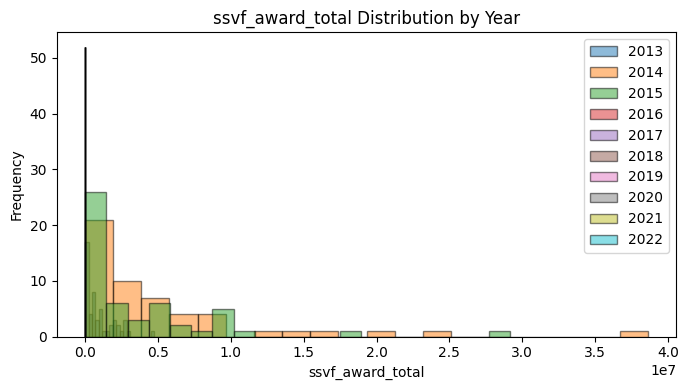

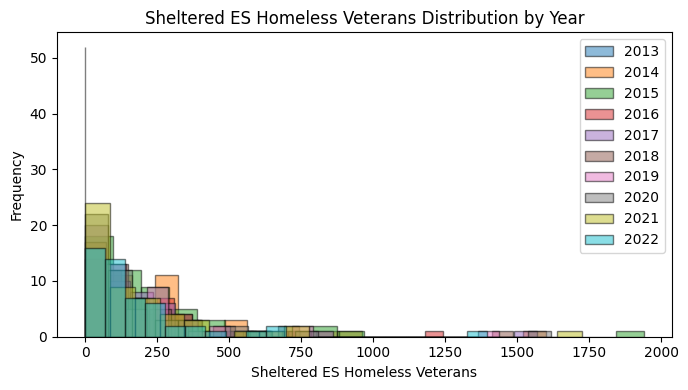

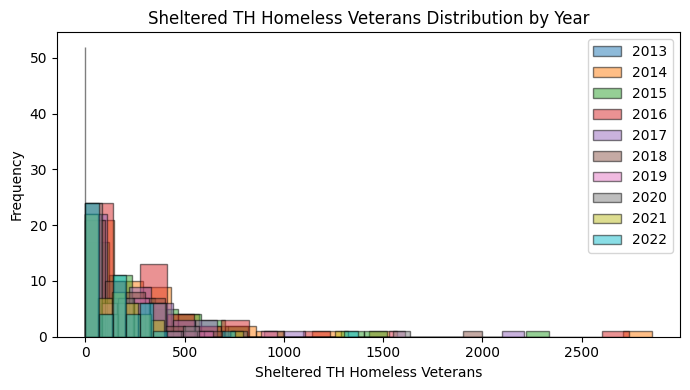

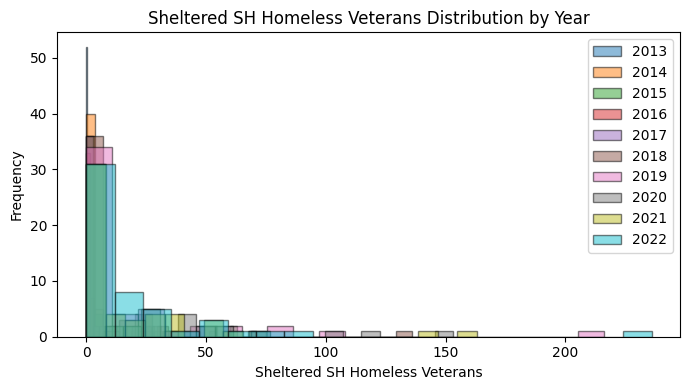

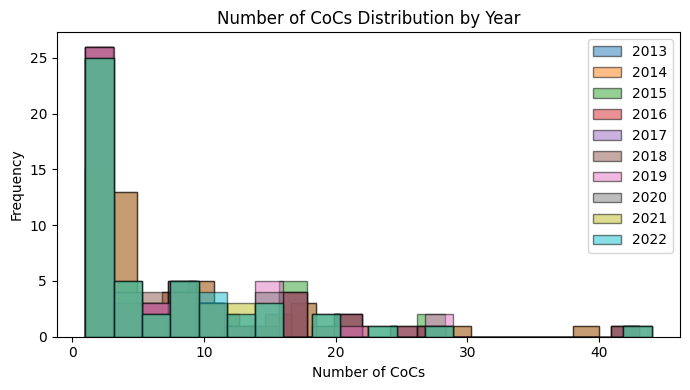

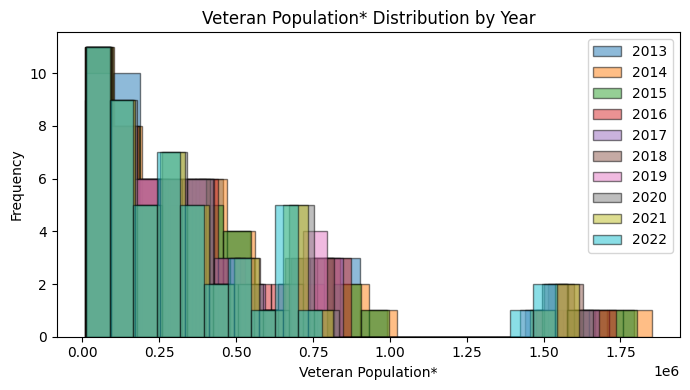

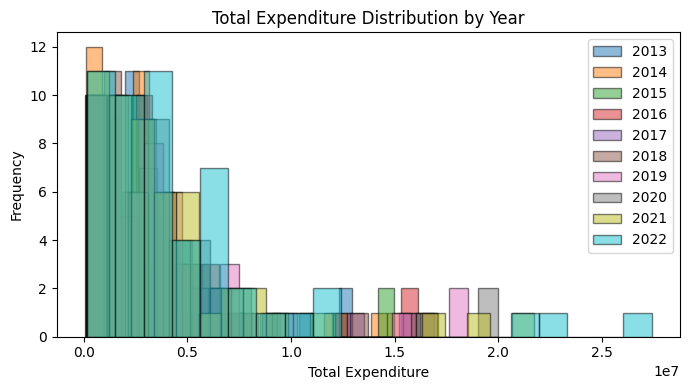

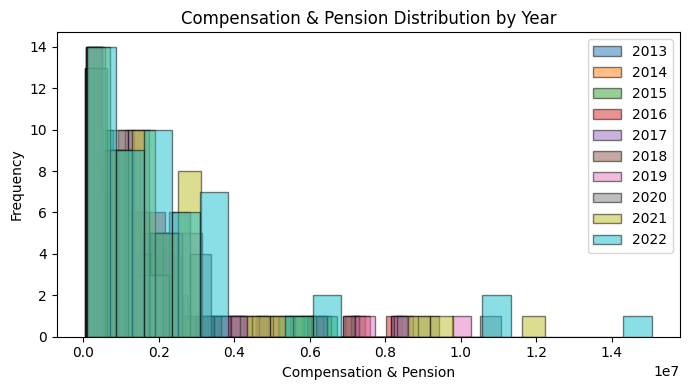

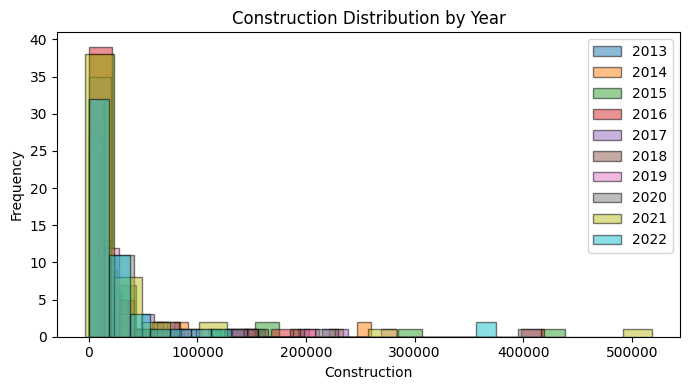

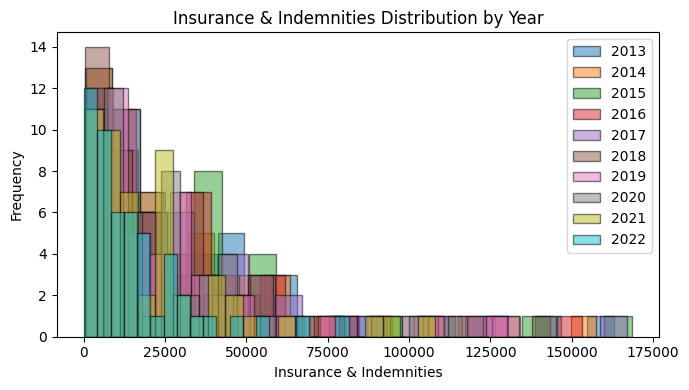

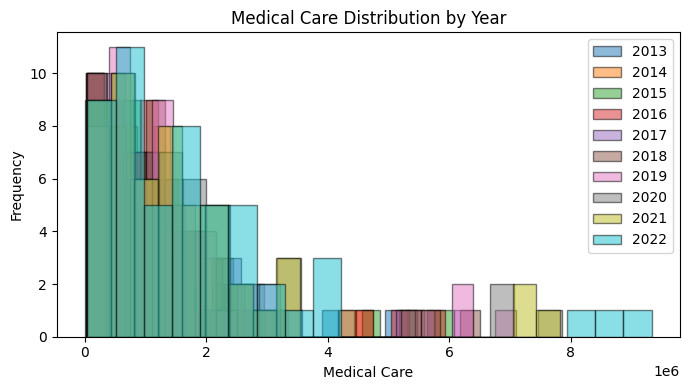

In [ ]:
#Histogram of a few of the numeric features
#I seperated it by year as I felt that was more valuable

#Keep in mind when this is re-ran, this is meant for df_zero.
#Combined_clean will have Nan values instead of zeros if everything were to be re-ran

import matplotlib.pyplot as plt
cols_to_plot = [
    'ssvf_award_total',
    'Sheltered ES Homeless Veterans',
    'Sheltered TH Homeless Veterans',
    'Sheltered SH Homeless Veterans',
    'Number of CoCs',
    'Veteran Population*',
    'Total Expenditure',
    'Compensation & Pension',
    'Construction',
    'Insurance & Indemnities',
    'Medical Care'
]

#d13 for 2013-2017
#df for 2013-2022
years = sorted(df['Year'].unique())
#I dont know the BIN size is so small for 1 of them, need to look at that
for col in cols_to_plot:
    plt.figure(figsize=(7, 4))
    for year in years:
        subset = df[df['Year'] == year][col]
        plt.hist(subset, bins=20, alpha=0.5, label=str(year), edgecolor='black')
    plt.title(f'{col} Distribution by Year')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()

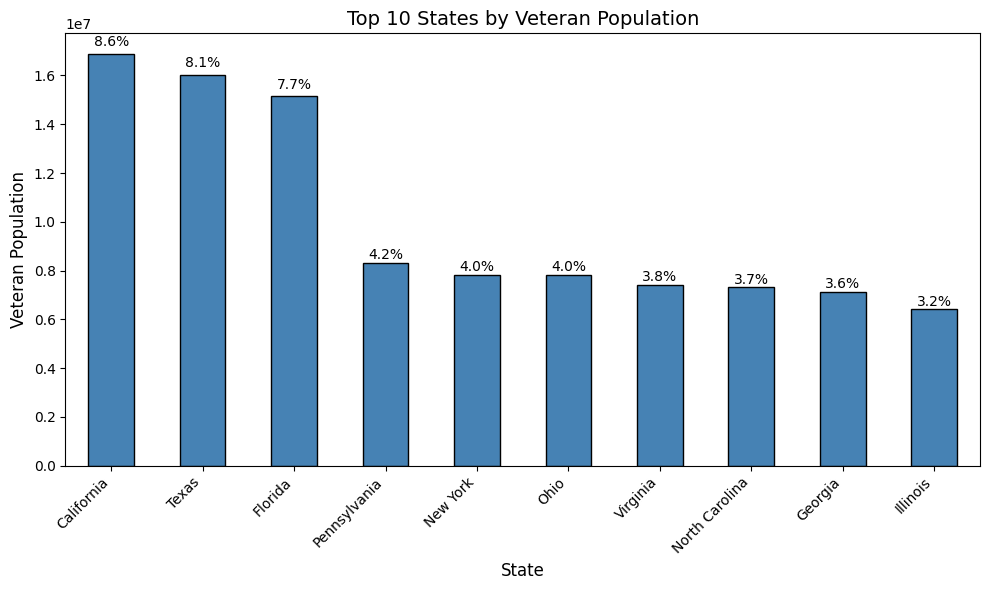

In [ ]:
import matplotlib.pyplot as plt

# Calculate total and top 10 states #d13 gives years 2013-2017
#d13 for 2013-2017
#df for 2013-2024
state_vets = df.groupby('State')['Veteran Population*'].sum().sort_values(ascending=False)
top10_vets = state_vets.head(10)
total_vets = state_vets.sum()

# Plot
plt.figure(figsize=(10,6))
bars = top10_vets.plot(kind='bar', color='steelblue', edgecolor='black')

plt.title('Top 10 States by Veteran Population', fontsize=14)
plt.xlabel('State', fontsize=12)
plt.ylabel('Veteran Population', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add percent labels
for i, value in enumerate(top10_vets):
    pct = (value / total_vets) * 100
    plt.text(i, value + (value * 0.02), f"{pct:.1f}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

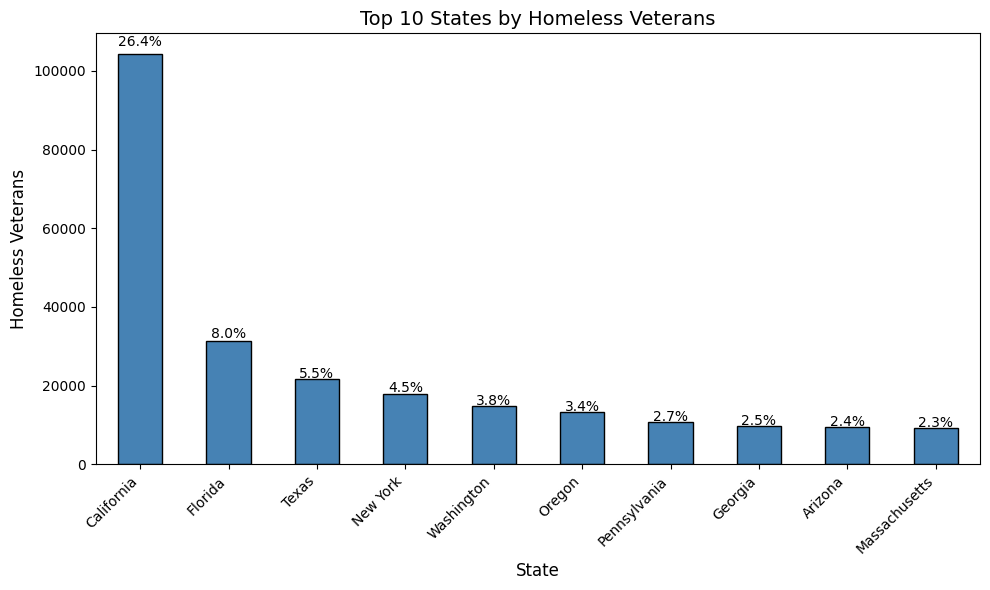

In [ ]:
import matplotlib.pyplot as plt

# Calculate total and top 10 states #d13 gives years 2013-2017
#d13 for 2013-2017
#df for 2013-2024
state_vets = df.groupby('State')['Homeless Veterans'].sum().sort_values(ascending=False)
top10_vets = state_vets.head(10)
total_vets = state_vets.sum()

# Plot
plt.figure(figsize=(10,6))
bars = top10_vets.plot(kind='bar', color='steelblue', edgecolor='black')

plt.title('Top 10 States by Homeless Veterans', fontsize=14)
plt.xlabel('State', fontsize=12)
plt.ylabel('Homeless Veterans', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add percent labels
for i, value in enumerate(top10_vets):
    pct = (value / total_vets) * 100
    plt.text(i, value + (value * 0.02), f"{pct:.1f}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

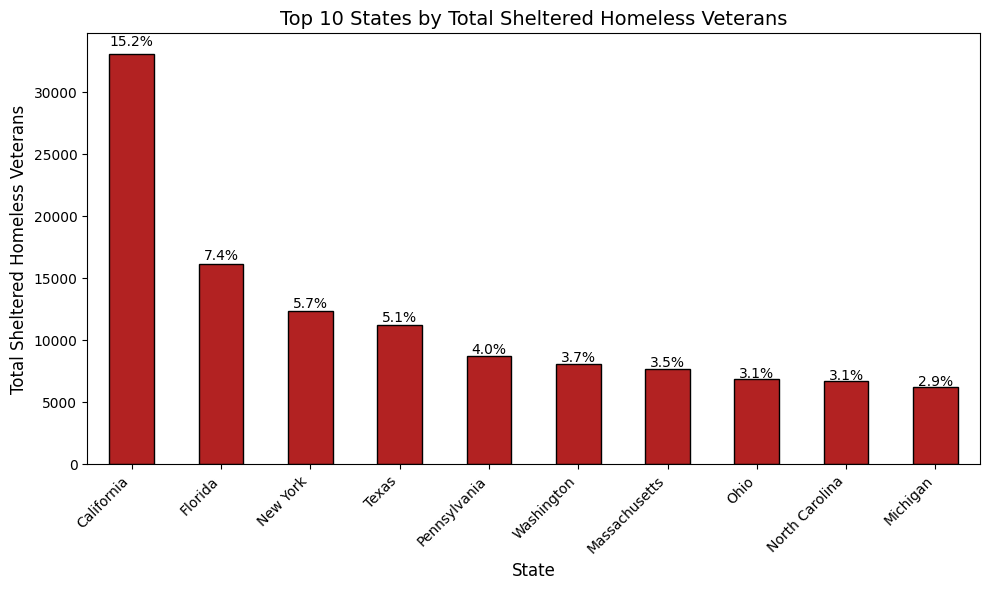

In [ ]:
# Recalculate total sheltered and top 10
#d13 for 2013-2017
#df for 2013-2022
df['Total Sheltered Homeless Veterans'] = (
    df['Sheltered ES Homeless Veterans'] +
    df['Sheltered TH Homeless Veterans'] +
    df['Sheltered SH Homeless Veterans']
)

state_sheltered = df.groupby('State')['Total Sheltered Homeless Veterans'].sum().sort_values(ascending=False)
top10_sheltered = state_sheltered.head(10)
total_sheltered = state_sheltered.sum()

# Plot
plt.figure(figsize=(10,6))
bars = top10_sheltered.plot(kind='bar', color='firebrick', edgecolor='black')

plt.title('Top 10 States by Total Sheltered Homeless Veterans', fontsize=14)
plt.xlabel('State', fontsize=12)
plt.ylabel('Total Sheltered Homeless Veterans', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add percent labels
for i, value in enumerate(top10_sheltered):
    pct = (value / total_sheltered) * 100
    plt.text(i, value + (value * 0.02), f"{pct:.1f}%", ha='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Calculate total and top 10 states #d13 gives years 2013-2017
#d13 for 2013-2017
#df for 2013-2022
state_vets = df.groupby('State')['Unsheltered Homeless Veterans'].sum().sort_values(ascending=False)
top10_vets = state_vets.head(10)
total_vets = state_vets.sum()

# Plot
plt.figure(figsize=(10,6))
bars = top10_vets.plot(kind='bar', color='steelblue', edgecolor='black')

plt.title('Unsheltered Homeless Veterans', fontsize=14)
plt.xlabel('State', fontsize=12)
plt.ylabel('Unsheltered Homeless Veterans', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add percent labels
for i, value in enumerate(top10_vets):
    pct = (value / total_vets) * 100
    plt.text(i, value + (value * 0.02), f"{pct:.1f}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

TypeError: unsupported operand type(s) for +: 'int' and 'str'

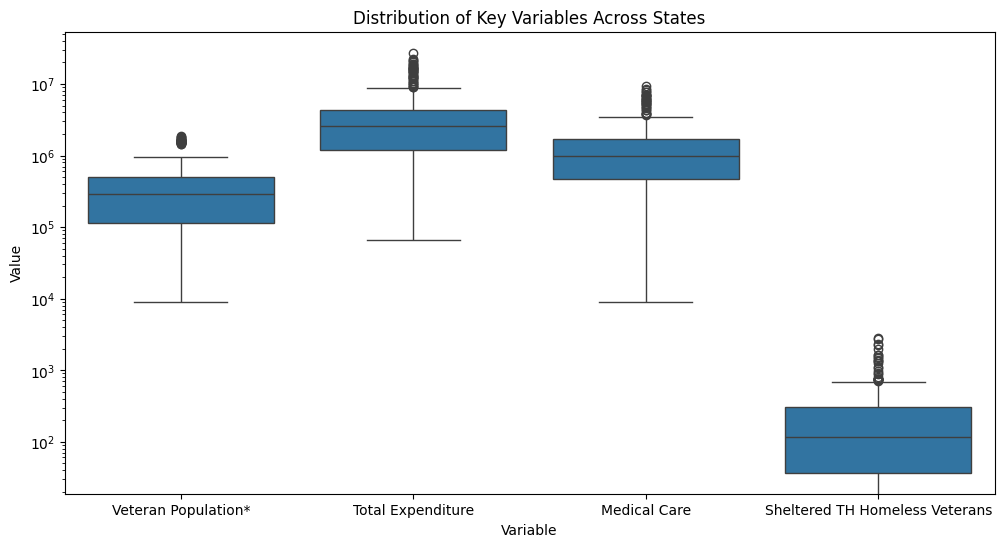

In [ ]:
numeric_cols = ['Veteran Population*', 'Total Expenditure', 'Medical Care',
                 'Sheltered TH Homeless Veterans']

df_melted = df.melt(id_vars='Year', value_vars=numeric_cols, var_name='Variable', value_name='Value')

plt.figure(figsize=(12,6))
sns.boxplot(data=df_melted, x='Variable', y='Value')
plt.yscale('log')  # highlight scale differences
#plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Key Variables Across States')
plt.show()

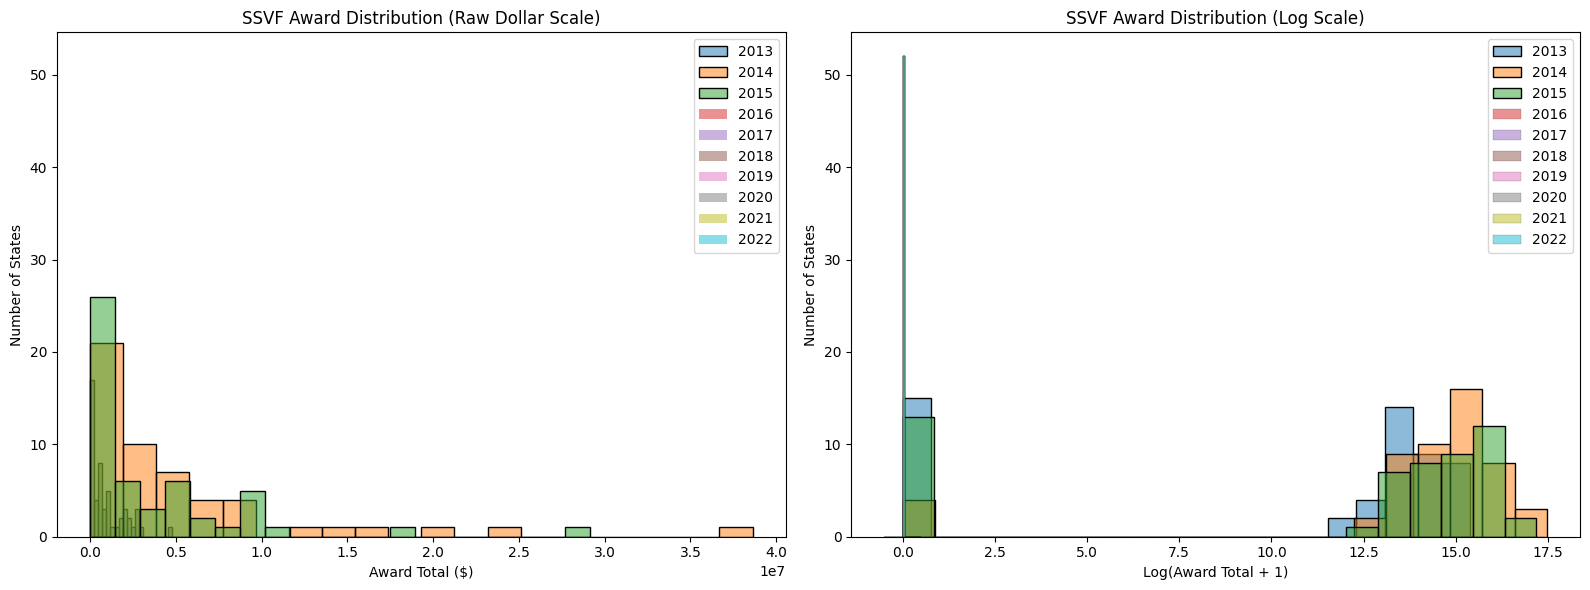

In [ ]:


# Columns and years
value_col = 'ssvf_award_total'
years = [2013, 2014, 2015, 2016,2017,2018,2019,2020,2021,2022,2023]

# Create a figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# 1️⃣ Raw dollar scale
for year in years:
    sns.histplot(df[df['Year'] == year][value_col],
                 bins=20, alpha=0.5, label=str(year), ax=axes[0])
axes[0].set_title('SSVF Award Distribution (Raw Dollar Scale)')
axes[0].set_xlabel('Award Total ($)')
axes[0].set_ylabel('Number of States')
axes[0].legend()

# 2️⃣ Log scale (log(x+1) to handle zeros)
for year in years:
    sns.histplot(np.log1p(df[df['Year'] == year][value_col]),
                 bins=20, alpha=0.5, label=str(year), ax=axes[1])
axes[1].set_title('SSVF Award Distribution (Log Scale)')
axes[1].set_xlabel('Log(Award Total + 1)')
axes[1].set_ylabel('Number of States')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px
state_abbrev = {
    'Alabama':'AL','Alaska':'AK','Arizona':'AZ','Arkansas':'AR','California':'CA','Colorado':'CO',
    'Connecticut':'CT','Delaware':'DE','District of Columbia':'DC','Florida':'FL','Georgia':'GA',
    'Hawaii':'HI','Idaho':'ID','Illinois':'IL','Indiana':'IN','Iowa':'IA','Kansas':'KS','Kentucky':'KY',
    'Louisiana':'LA','Maine':'ME','Maryland':'MD','Massachusetts':'MA','Michigan':'MI','Minnesota':'MN',
    'Mississippi':'MS','Missouri':'MO','Montana':'MT','Nebraska':'NE','Nevada':'NV','New Hampshire':'NH',
    'New Jersey':'NJ','New Mexico':'NM','New York':'NY','North Carolina':'NC','North Dakota':'ND','Ohio':'OH',
    'Oklahoma':'OK','Oregon':'OR','Pennsylvania':'PA','Rhode Island':'RI','South Carolina':'SC','South Dakota':'SD',
    'Tennessee':'TN','Texas':'TX','Utah':'UT','Vermont':'VT','Virginia':'VA','Washington':'WA',
    'West Virginia':'WV','Wisconsin':'WI','Wyoming':'WY'
}

d13['state_abbrev'] = d13['State'].map(state_abbrev)

fig = px.choropleth(
    d13[d13['Year']==2014],  # choose a year
    locations='state_abbrev',
    locationmode='USA-states',
    color='ssvf_award_total',
    color_continuous_scale='Viridis',
    scope='usa',
    labels={'ssvf_award_total':'SSVF Award Total'},
    title='SSVF Award Total by State in 2015'
)
fig.show()

In [ ]:
# I forgot Alabama is just not in our dataset. I believe this is my fault, I should be able to just add it in later

SEction 3.1 State level EDA

In [ ]:
import pandas as pd
import numpy as np

def summarize_distributions(df, state_col, variables):
    """
    df: full panel dataset
    state_col: column name for state
    variables: list of variable column names

    Returns: DataFrame of summary statistics by state and variable
    """

    summary_list = []

    for state, state_df in df.groupby(state_col):
        for var in variables:

            series = state_df[var].dropna()

            if len(series) == 0:
                continue

            summary_list.append({
                "State": state,
                "Variable": var,
                "N": len(series),
                "Mean": series.mean(),
                "Std": series.std(),
                "Min": series.min(),
                "25%": series.quantile(0.25),
                "Median": series.median(),
                "75%": series.quantile(0.75),
                "Max": series.max(),
                "Skewness": series.skew()
            })

    return pd.DataFrame(summary_list)


In [ ]:
#df = pd.read_csv("ssvf_Zero (1).csv")  # or pd.read_excel("your_dataset.xlsx")
variables = ["ssvf_award_total", "Homeless Veterans", "Total Expenditure"]

dist_summary = summarize_distributions(df, "State", variables)

dist_summary.head()


,State,Variable,N,Mean,Std,Min,25%,Median,75%,Max,Skewness
0,Alaska,ssvf_award_total,11,9.630342e+05,3.423684e+05,3.978790e+05,7.718510e+05,7.912400e+05,1.319974e+06,1.427515e+06,0.177814
1,Alaska,Homeless Veterans,11,1.350909e+02,4.799261e+01,3.600000e+01,1.150000e+02,1.320000e+02,1.730000e+02,2.100000e+02,-0.482446
2,Alaska,Total Expenditure,11,7.401871e+05,1.664816e+05,5.016043e+05,6.119906e+05,7.240702e+05,8.493367e+05,1.004793e+06,0.216935
3,Arizona,ssvf_award_total,11,8.018711e+06,1.890755e+06,2.477610e+06,8.185023e+06,8.266539e+06,8.859885e+06,9.509176e+06,-2.973015
4,Arizona,Homeless Veterans,11,9.505455e+02,1.660641e+02,6.370000e+02,8.755000e+02,9.210000e+02,1.003000e+03,1.222000e+03,0.199434


In [ ]:
import matplotlib.pyplot as plt

def plot_state_distributions(df, state, variables):

    state_df = df[df["State"] == state]

    for var in variables:
        plt.figure()
        plt.hist(state_df[var].dropna(), bins=10)
        plt.title(f"{state} - {var}")
        plt.xlabel(var)
        plt.ylabel("Frequency")
        plt.show()


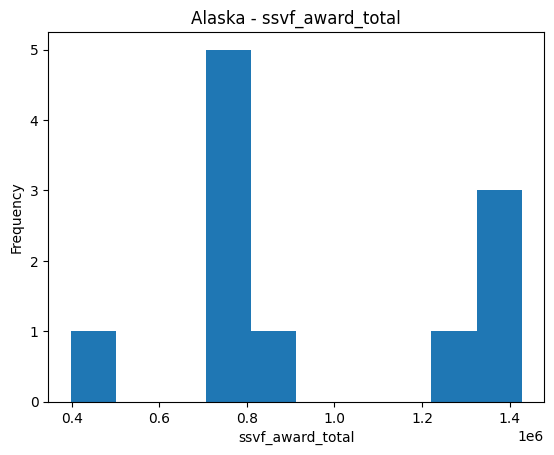

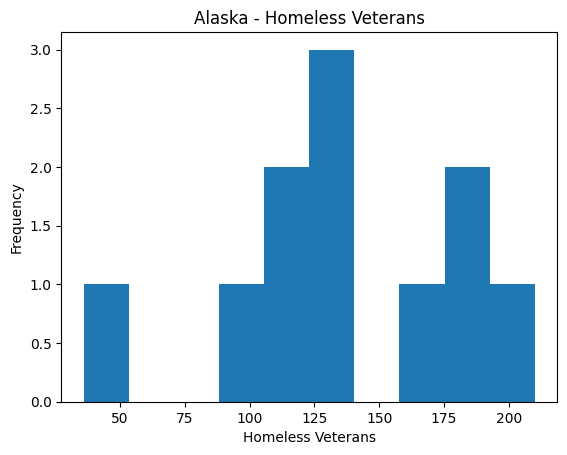

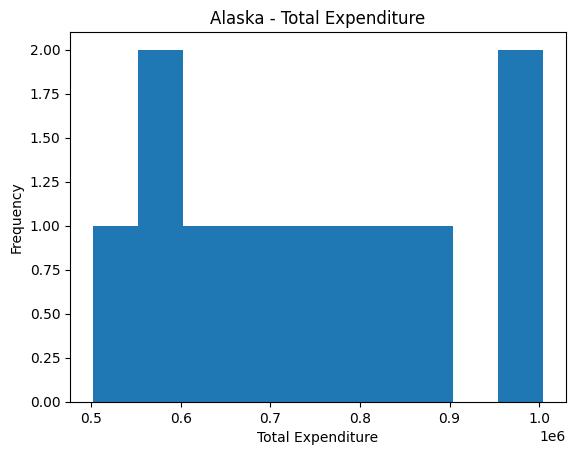

In [ ]:
plot_state_distributions(df, "Alaska", variables)


In [ ]:
def plot_state_time_series(df, state, variables, year_col):

    state_df = df[df["State"] == state]

    for var in variables:
        df[var] = np.log(df[var])
        df[var] = df[var].diff()

        plt.figure()
        plt.plot(state_df[year_col], state_df[var])
        plt.title(f"{state} - {var} Over Time")
        plt.xlabel("Year")
        plt.ylabel(var)
        plt.show()


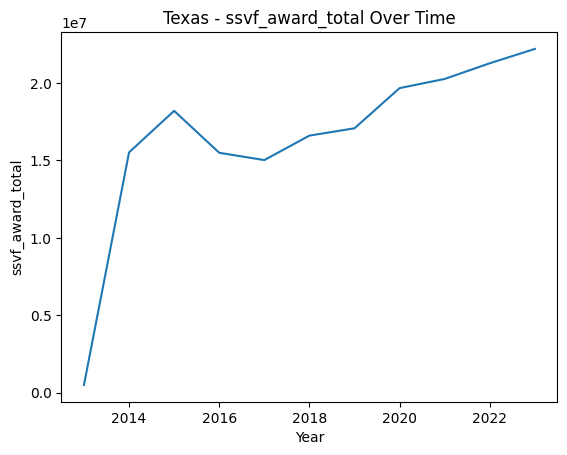

TypeError: loop of ufunc does not support argument 0 of type int which has no callable log method

In [ ]:
plot_state_time_series(df,"Texas",variables,"Year")

In [ ]:
def plot_state_time_series_n(df, state, variables, year_col):
#Without scaled values
    state_df = df[df["State"] == state]

    for var in variables:


        plt.figure()
        plt.plot(state_df[year_col], state_df[var])
        plt.title(f"{state} - {var} Over Time")
        plt.xlabel("Year")
        plt.ylabel(var)
        plt.show()


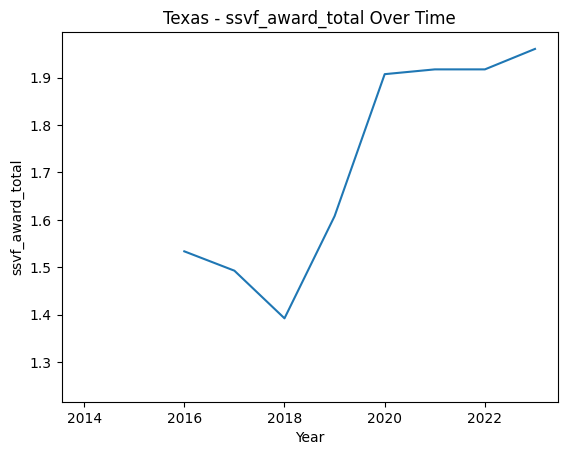

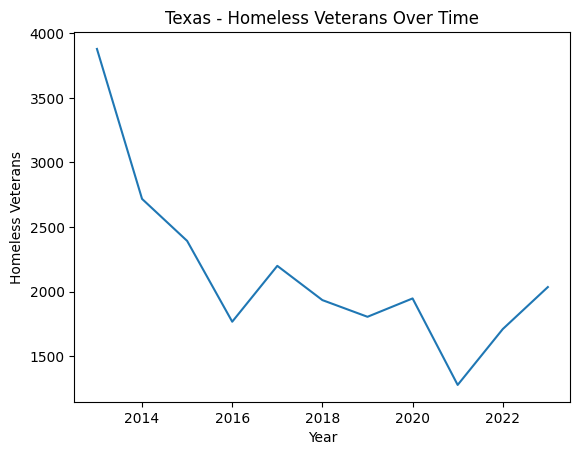

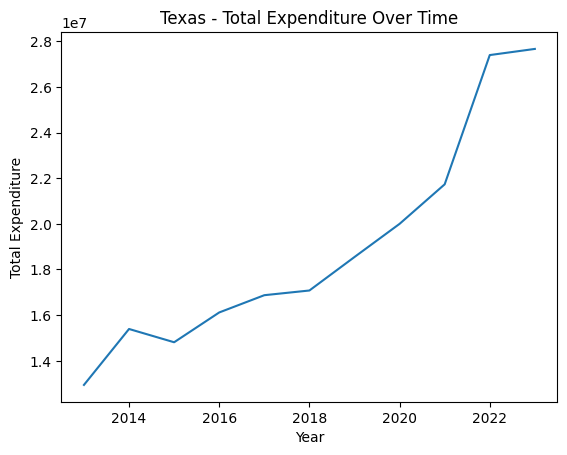

In [ ]:
plot_state_time_series_n(df,"Texas",variables,"Year")

In [ ]:
state_df = df[df["State"] == "Alaska"].copy()

for var in variables:
    state_df[var] = np.log(state_df[var]).diff()

state_df = state_df.dropna()

model = VAR(state_df[variables])
results = model.fit(1)

print("Stable:", results.is_stable())


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


TypeError: loop of ufunc does not support argument 0 of type int which has no callable log method

In [ ]:
df.head()

,State,ssvf_award_total,Number of CoCs,Homeless Veterans,Sheltered Total Homeless Veterans,Unsheltered Homeless Veterans,Year,Veteran Population*,Total Expenditure,Compensation & Pension,...,Education & Vocational Rehabilitation/ Employment,Loan Guaranty#,General Operating Expenses,Insurance & Indemnities,Medical Care,Unique Patients **,Sheltered ES Homeless Veterans,Sheltered TH Homeless Veterans,Sheltered SH Homeless Veterans,Total Sheltered Homeless Veterans
0,Alaska,NaN,2.0,210,188,22,2013,7.467068e+04,5.016043e+05,211259.883,...,61849.811,0.0,6686.46092,3440.637630,2.177514e+05,17304,0,0,0,0
1,Arizona,1.828902,3.0,1222,901,321,2013,5.273995e+05,3.220905e+06,1409346.495,...,343819.709,0.0,108885.30599,36145.366830,1.301507e+06,137362,0,0,0,0
2,Arkansas,-1.609676,6.0,462,326,136,2013,2.500950e+05,1.946615e+06,924670.594,...,79062.838,0.0,31331.48548,13484.362350,8.901269e+05,86763,0,0,0,0
3,California,2.262758,40.0,12895,4886,8009,2013,1.795455e+06,1.270754e+07,5397860.031,...,1599760.457,0.0,192392.35384,162955.519115,5.209559e+06,444432,0,0,0,0
4,Colorado,-0.872407,3.0,685,452,233,2013,3.908238e+05,2.594677e+06,1212142.876,...,324347.441,0.0,62854.32576,32483.449280,8.502349e+05,90822,0,0,0,0


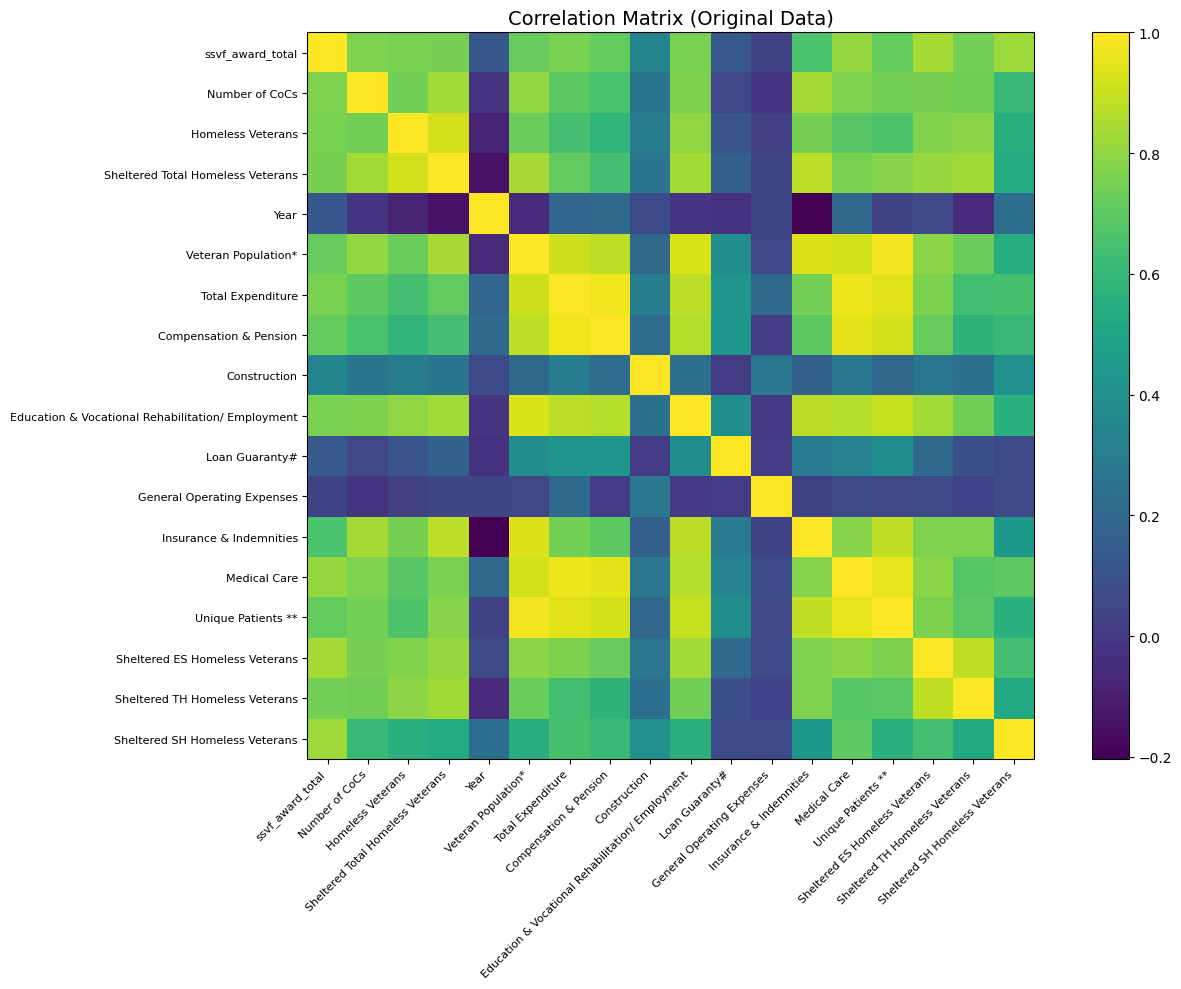

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
#Entire dataset
# Correlation matrix
corr_df = df.select_dtypes(include=['number'])
corr_matrix = corr_df.corr()

# Create figure with larger size
plt.figure(figsize=(14, 10))

# Plot heatmap
plt.imshow(corr_matrix)

# Add colorbar
plt.colorbar()

# Clean axis labels
labels = corr_matrix.columns

plt.xticks(range(len(labels)), labels, rotation=45, ha='right', fontsize=8)
plt.yticks(range(len(labels)), labels, fontsize=8)

plt.title("Correlation Matrix (Original Data)", fontsize=14)

plt.tight_layout()
plt.show()

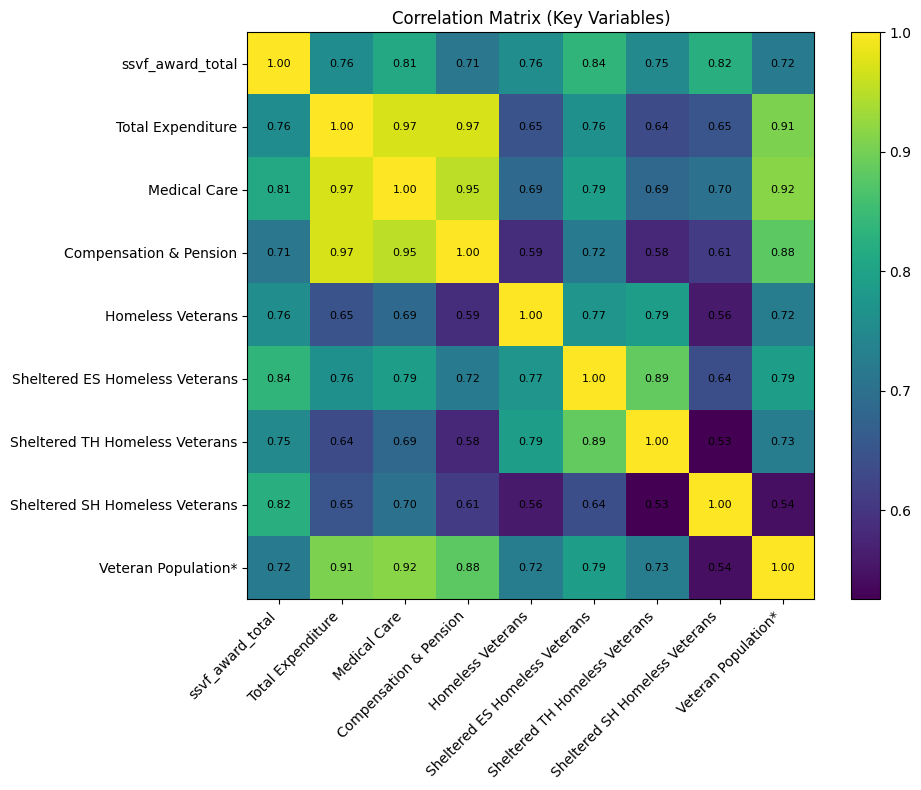

In [ ]:
#Chosen Variables
key_vars = [
    'ssvf_award_total',
    'Total Expenditure',
    'Medical Care',
    'Compensation & Pension',
    'Homeless Veterans',
    'Sheltered ES Homeless Veterans',
    'Sheltered TH Homeless Veterans',
    'Sheltered SH Homeless Veterans',
    'Veteran Population*'
]

corr_matrix = df[key_vars].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix)
plt.colorbar()

plt.xticks(range(len(key_vars)), key_vars, rotation=45, ha='right')
plt.yticks(range(len(key_vars)), key_vars)

# 🔥 Add correlation values inside boxes
for i in range(len(key_vars)):
    for j in range(len(key_vars)):
        value = corr_matrix.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha='center', va='center', fontsize=8)
plt.title("Correlation Matrix (Key Variables)")
plt.tight_layout()
plt.show()

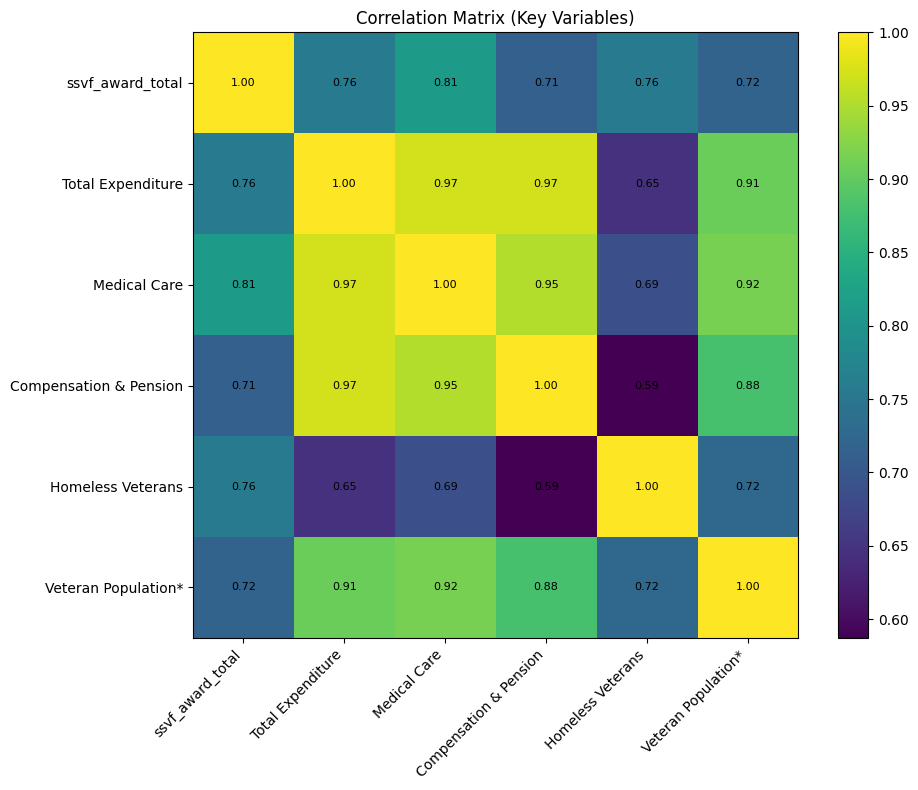

In [ ]:
#Chosen Variables more precise
key_vars = [
    'ssvf_award_total',
    'Total Expenditure',
    'Medical Care',
    'Compensation & Pension',
    'Homeless Veterans',
    'Veteran Population*'
]

corr_matrix = df[key_vars].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix)
plt.colorbar()

plt.xticks(range(len(key_vars)), key_vars, rotation=45, ha='right')
plt.yticks(range(len(key_vars)), key_vars)

# 🔥 Add correlation values inside boxes
for i in range(len(key_vars)):
    for j in range(len(key_vars)):
        value = corr_matrix.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha='center', va='center', fontsize=8)
plt.title("Correlation Matrix (Key Variables)")
plt.tight_layout()
plt.show()

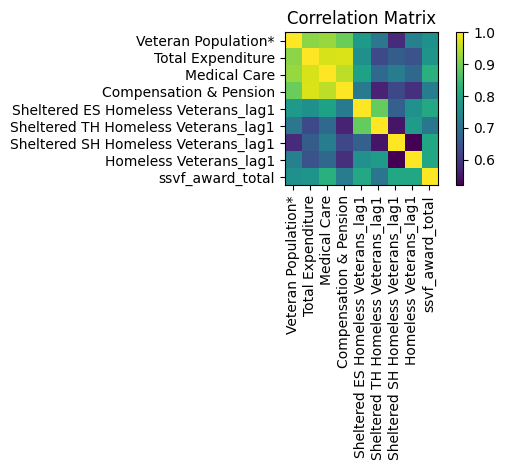

In [ ]:
#Lagged XGBoost dataset matric, will only work after running model
import matplotlib.pyplot as plt
import numpy as np

# Select numeric columns only (important)
corr_df = df_model[predictors + [target]]

# Compute correlation matrix
corr_matrix = corr_df.corr()

# Plot
plt.figure()
plt.imshow(corr_matrix)
plt.colorbar()

# Axis labels
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## **Section 4**

Running some models

## 4.1 Standard XGBoost

In [ ]:
#run when looking at new dataset
#df = pd.read_csv("ssvf_Zero (1).csv")

In [ ]:
#Just running xgboost here. Not the best model for the question, but gives some information


from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# would be cool Try changing between combined_clean and df_zero #d13 gives years 2013-2017
df_no_state = df.drop(columns=['State'])
# Example target
target = 'ssvf_award_total'


#Using certian features for modeling
#For a simple fix I got rid of the types of shetlered, becuase the filled in zeros were
#giving weight to something I did not want to have weight

#Getting rid of the sheltered types reduced R^2 to .15
selected_features= [
    'Sheltered ES Homeless Veterans',
    'Sheltered TH Homeless Veterans',
    'Sheltered SH Homeless Veterans',
    'Number of CoCs',
    'Veteran Population*',
    'Total Expenditure',
    'Compensation & Pension',
    'Insurance & Indemnities',
    'Medical Care'
]

#Using certian columns: .672 with all features
# .150 without ES,TH,SH
# .679 without Insurance & Indemnities
# .678 without Construction
X = df_no_state[selected_features]

# Keep only numeric columns: got .422 for R^2
#X = df_no_state.select_dtypes(include='number').drop(columns=[target])

#Y will be same regardless of chosen X
y = df_no_state[target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoost baseline
model = XGBRegressor(random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
# Below comment used once scikit updated
#rmse = mean_squared_error(y_test, y_pred, squared=False)

#manual Rsme while not upgraded scikit
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

#We should probably look into what a "Good" value is

RMSE: 3642769.73
R²: 0.869


In [ ]:
import numpy as np

print("NaN in y_train:", np.isnan(y_train).sum())
print("Inf in y_train:", np.isinf(y_train).sum())
print("Max value:", np.max(y_train))
print("Min value:", np.min(y_train))

NaN in y_train: 1
Inf in y_train: 0
Max value: 4.557522039419764
Min value: -3.848407823158931


In [ ]:
# =========================
# SHAP for Standard XGBoost
# =========================
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Use the same X, y, X_train, X_test, y_train, y_test, and model from your XGBoost cell
# model should already be fitted

# Create SHAP explainer
explainer = shap.Explainer(model, X_train)

# Compute SHAP values on test set
shap_values = explainer(X_test)

# 1. Summary plot
plt.figure()
shap.plots.beeswarm(shap_values, max_display=10)

# 2. Bar plot of overall importance
plt.figure()
shap.plots.bar(shap_values, max_display=10)

# 3. Mean absolute SHAP values table
shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean_Abs_SHAP": np.abs(shap_values.values).mean(axis=0)
}).sort_values("Mean_Abs_SHAP", ascending=False)

print(shap_importance)

# Optional: save results
shap_importance.to_csv("xgboost_shap_importance.csv", index=False)

Sooooo... with the addition of a couple years, the R^2 jumped from 0.671, all the way to 0.946.

I used 2013-2015 for the 0.671
I used 2013-2017 for the 0.946
I used 2013-2023 for the 0.869

2013-2023 used mean and median for ssvf_award_total
I mentioned earlier, I did replace some zeros with values. The variable was the target variable so that probably made a big difference. I also added 2 years.

In all honesty, I am very skeptical of this massive jump in accuracy. As stated, however, the XGBoost isn't exactl predicting what I want it to.

It is just choosing some random years and making predictions of the amount. From my understanding, despite the high accuracy, this doesn't exactly help with our question.

Fitting 5 folds for each of 40 candidates, totalling 200 fits
✅ Best Parameters:
{'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 0.8}

🏆 Best (mean CV) RMSE: 2534728.1450


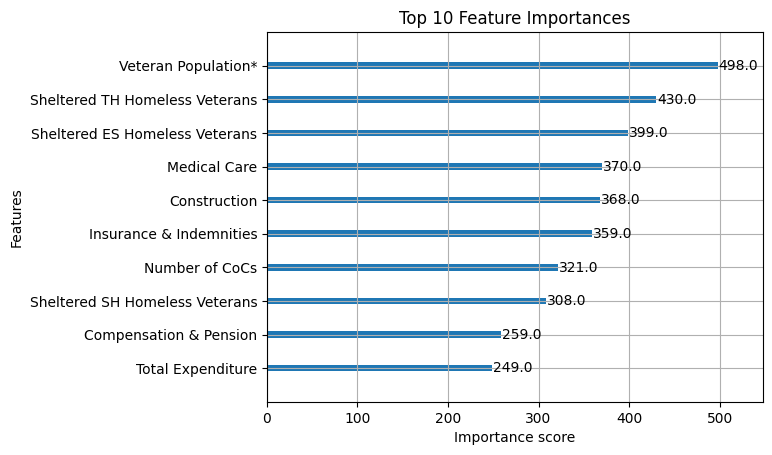

In [ ]:
# The main reason I decided to keep the XGBoost in the code is that I can look at some feature importance
# at least in regards to the XGBoost model
# Honestly, just go this from chat

# =========================================
# Step 1. Imports
# =========================================
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import make_scorer, mean_squared_error
import numpy as np

# =========================================
# Step 2. Prepare data
# =========================================
target = 'ssvf_award_total'
X = df_no_state.select_dtypes(include='number').drop(columns=[target], errors='ignore')
y = df_no_state[target]

# 5-fold CV (you can try GroupKFold if states are correlated)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# =========================================
# Step 3. Define parameter grid
# =========================================
param_dist = {
    'n_estimators': [200, 400, 600, 800, 1000],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.3, 0.5, 1],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [0.5, 1, 2, 5]
}

# RMSE scorer (note: we negate it since RandomizedSearchCV maximizes the score)
rmse_scorer = make_scorer(
    lambda y_true, y_pred: -np.sqrt(mean_squared_error(y_true, y_pred))
)

# =========================================
# Step 4. Randomized Search
# =========================================
xgb = XGBRegressor(
    objective='reg:squarederror',
    n_jobs=-1,
    random_state=42
)

rs = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=40,        # try 40 random combinations
    scoring=rmse_scorer,
    cv=cv,
    random_state=42,
    verbose=2,
    n_jobs=-1
)

rs.fit(X, y)

# =========================================
# Step 5. Results
# =========================================
print("✅ Best Parameters:")
print(rs.best_params_)
print()
print(f"🏆 Best (mean CV) RMSE: {-rs.best_score_:.4f}")

# Train final model with the best parameters
best_xgb = rs.best_estimator_
best_xgb.fit(X, y)

# Optional: feature importance plot
import matplotlib.pyplot as plt
import xgboost as xgb
xgb.plot_importance(best_xgb, max_num_features=10)
plt.title("Top 10 Feature Importances")
plt.show()


## 4.2 Lagged XGBoost

In [ ]:
#Use if just plugging in dataset
import pandas as pd
df = pd.read_csv("ssvf.csv")

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
import numpy as np

In [ ]:
#Looking at what would happen if comined certian varaibles
df['Spending_Index'] = (
    df['Total Expenditure'] +
    df['Medical Care'] +
    df['Compensation & Pension']
)

In [ ]:
#This lagged XGBoost is closer to the forecasting goal we actually eant. The XGBOoost above is stil
# valubale and gives some insight on the data
#Also, we are splitting it by year here unlike earlier

#This is supposed to be closer to answering our actual question
import pandas as pd

# Sort for consistent lagging
df_sort = df.sort_values(by=['State', 'Year'])

# Columns to create lagged versions of
lag_columns = [
    'Sheltered ES Homeless Veterans',
    'Sheltered TH Homeless Veterans',
    'Sheltered SH Homeless Veterans',
    'Homeless Veterans',
    'Veteran Population*',
    'Spending_Index'
]

# Create lagged columns per state
for col in lag_columns:
    df_sort[f'{col}_lag1'] = df_sort.groupby('State')[col].shift(1)

# Drop first year for each state (no lag data)
df_lagged = df_sort.dropna(subset=[f'{col}_lag1' for col in lag_columns])

# Target
target = 'ssvf_award_total'

# Predictor set
predictors = [
    # same-year
    'Veteran Population*',
    'Spending_Index',

    # lagged
    'Sheltered ES Homeless Veterans_lag1',
    'Sheltered TH Homeless Veterans_lag1',
    'Sheltered SH Homeless Veterans_lag1',
    'Homeless Veterans_lag1',

    # add categorical (encoded) later
]

# Drop rows with NaNs in predictors or target
df_model = df_lagged.dropna(subset=predictors + [target])

# Time-based split
train = df_model[df_model['Year'] <= 2022]
test = df_model[df_model['Year'] == 2023]

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# One-hot encode State
# One-hot encode AFTER splitting (important!)
X_train = pd.get_dummies(train[['State'] + predictors], drop_first=True)
X_test = pd.get_dummies(test[['State'] + predictors], drop_first=True)

y_train = train[target]
y_test = test[target]

# Align columns (in case some states only appear in one split)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Model
model = XGBRegressor(
    random_state=42,
    n_estimators=300,#500 overfit
    learning_rate=0.05,
    max_depth=3, #5 overfit
    subsample=0.7,
    colsample_bytree=0.7,
    reg_lambda=1.0,          # L2 regularization didnt have
    reg_alpha=0.5            # L1 regularization didnthave
)

model.fit(X_train, y_train)

# Train predict
y_train_pred = model.predict(X_train)

# Train metrics
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

# Test Predict
y_pred = model.predict(X_test)

# Test Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Train Metrics:")
print(f"RMSE: {rmse_train:,.2f}")
print(f"R²: {r2_train:.3f}")

print("\nTest Metrics:")
print(f"RMSE: {rmse:,.2f}")
print(f"R²: {r2:.3f}")


Train Metrics:
RMSE: 881,977.18
R²: 0.991

Test Metrics:
RMSE: 2,108,502.26
R²: 0.970


In [ ]:
#Same as above, just testing other things out

#This is supposed to be closer to answering our actual question
import pandas as pd

# Sort for consistent lagging
df_sort = df.sort_values(by=['State', 'Year'])

# Columns to create lagged versions of
lag_columns = [
    'Sheltered ES Homeless Veterans',
    'Sheltered TH Homeless Veterans',
    'Sheltered SH Homeless Veterans',
    'Homeless Veterans',
    'Veteran Population*',
    'Total Expenditure',
    'Medical Care',
    'Compensation & Pension'
]

# Create lagged columns per state
for col in lag_columns:
    df_sort[f'{col}_lag1'] = df_sort.groupby('State')[col].shift(1)

# Drop first year for each state (no lag data)
df_lagged = df_sort.dropna(subset=[f'{col}_lag1' for col in lag_columns])

# Target
target = 'ssvf_award_total'

# Predictor set
predictors = [
    # same-year
    'Veteran Population*',
    'Total Expenditure',
    'Medical Care',
    'Compensation & Pension',

    # lagged
    'Sheltered ES Homeless Veterans_lag1',
    'Sheltered TH Homeless Veterans_lag1',
    'Sheltered SH Homeless Veterans_lag1',
    'Homeless Veterans_lag1',

    # add categorical (encoded) later
]

# Drop rows with NaNs in predictors or target
df_model = df_lagged.dropna(subset=predictors + [target])

# Time-based split
train = df_model[df_model['Year'] <= 2022]
test = df_model[df_model['Year'] == 2023]

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# One-hot encode State
# One-hot encode AFTER splitting (important!)
X_train = pd.get_dummies(train[['State'] + predictors], drop_first=True)
X_test = pd.get_dummies(test[['State'] + predictors], drop_first=True)

y_train = train[target]
y_test = test[target]

# Align columns (in case some states only appear in one split)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Model
model = XGBRegressor(
    random_state=42,
    n_estimators=300,#500 overfit
    learning_rate=0.05,
    max_depth=3, #5 overfit
    subsample=0.7,
    colsample_bytree=0.7,
    reg_lambda=1.0,          # L2 regularization didnt have
    reg_alpha=0.5            # L1 regularization didnthave
)

model.fit(X_train, y_train)

# Train predict
y_train_pred = model.predict(X_train)

# Train metrics
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

# Test Predict
y_pred = model.predict(X_test)

# Test Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Train Metrics:")
print(f"RMSE: {rmse_train:,.2f}")
print(f"R²: {r2_train:.3f}")

print("\nTest Metrics:")
print(f"RMSE: {rmse:,.2f}")
print(f"R²: {r2:.3f}")


Train Metrics:
RMSE: 879,938.02
R²: 0.991

Test Metrics:
RMSE: 1,740,514.45
R²: 0.980


In [ ]:
print(X_train.dtypes[X_train.dtypes == 'object'])

Series([], dtype: object)


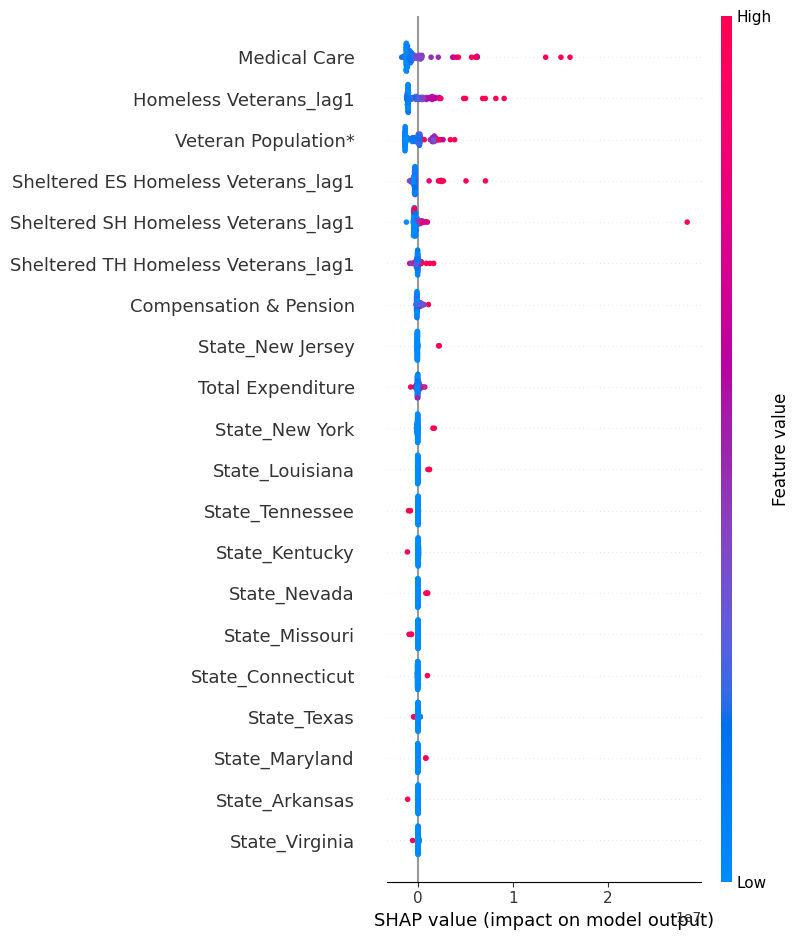

In [ ]:
#Global SHAP
import shap

# Convert to pure numeric arrays
X_train_np = X_train.to_numpy(dtype=float)
X_test_np = X_test.to_numpy(dtype=float)

# Use TreeExplainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_np)

# Plot (use original column names)
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)

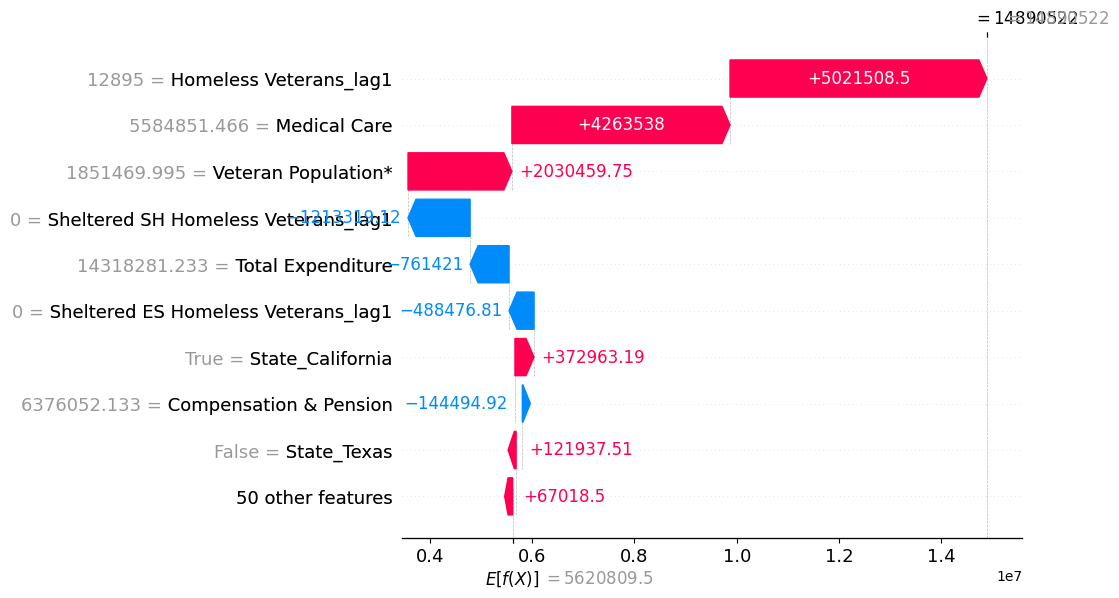

In [ ]:
X_test_ca = X_test[X_test['State_California'] == 1]
X_test_ca_np = X_test_ca.to_numpy(dtype=float)

shap_values_ca = explainer.shap_values(X_test_ca_np)
i = 0  # or any index
# California
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_ca[i],
        base_values=explainer.expected_value,
        data=X_test_ca.iloc[i],
        feature_names=X_test.columns
    )
)

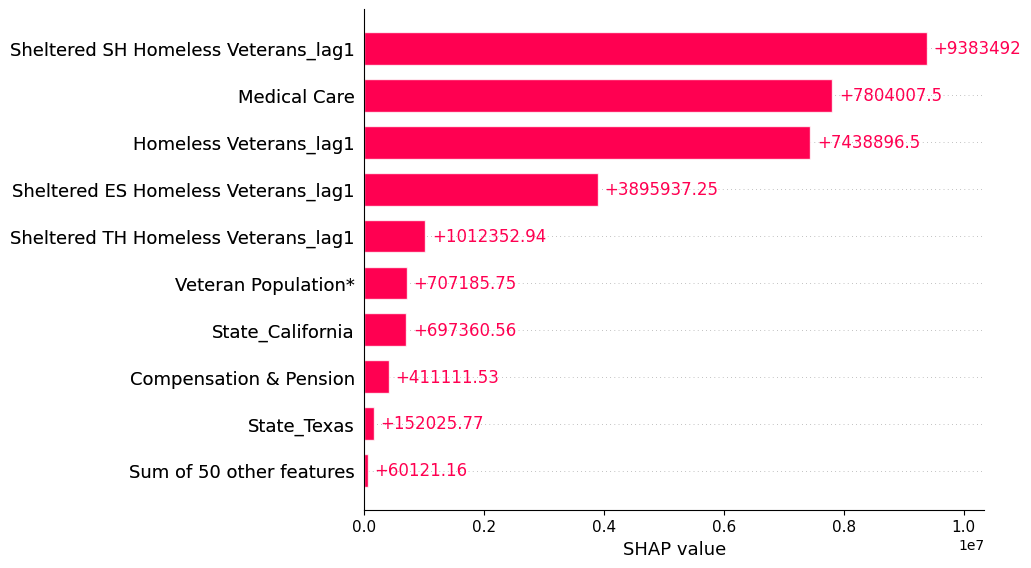

In [ ]:
import numpy as np

mean_shap_ca = np.mean(shap_values_ca, axis=0)

shap.plots.bar(
    shap.Explanation(
        values=mean_shap_ca,
        base_values=explainer.expected_value,
        feature_names=X_test.columns
    )
)

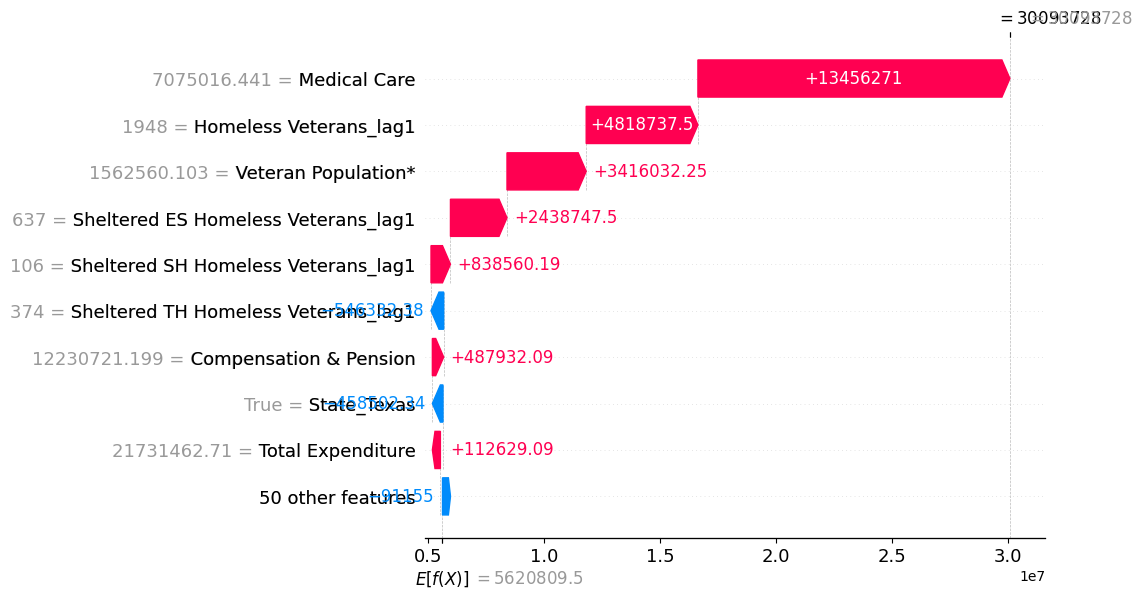

In [ ]:
X_test_tx = X_test[X_test['State_Texas'] == 1]
X_test_tx_np = X_test_tx.to_numpy(dtype=float)

shap_values_tx = explainer.shap_values(X_test_tx_np)
i = 0  # or any index
# Texas
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_tx[i],
        base_values=explainer.expected_value,
        data=X_test_tx.iloc[i],
        feature_names=X_test.columns
    )
)

## NEW lagged xgboost shap values

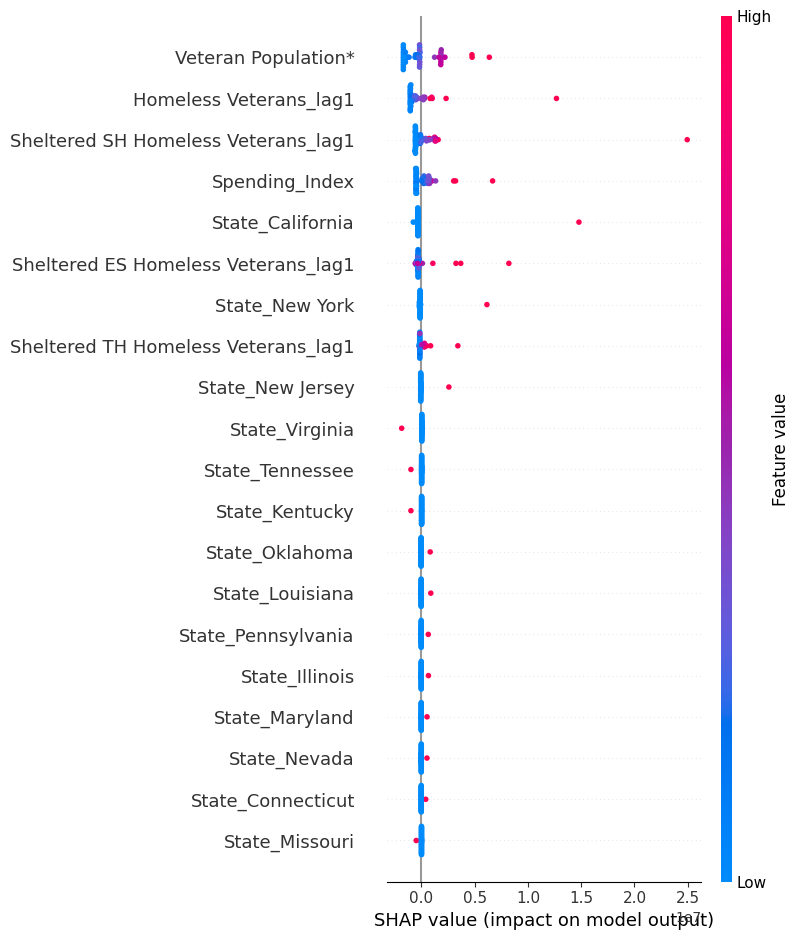

In [ ]:
#Global SHAP
import shap

# Convert to pure numeric arrays
X_train_np = X_train.to_numpy(dtype=float)
X_test_np = X_test.to_numpy(dtype=float)

# Use TreeExplainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_np)

# Plot (use original column names)
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)

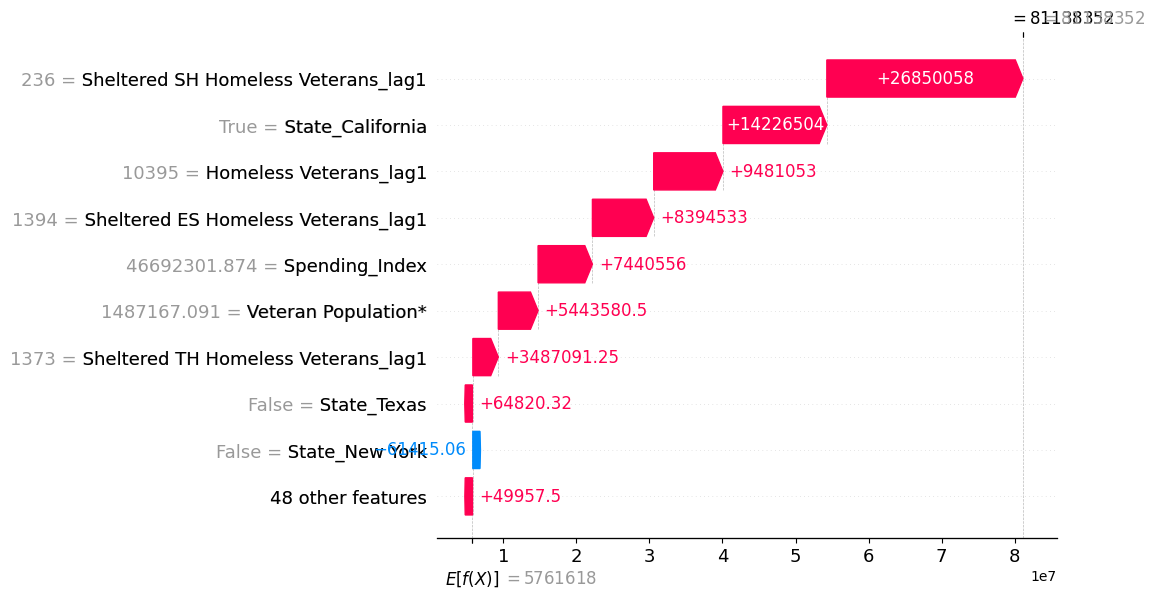

In [ ]:
#California
X_test_ca = X_test[X_test['State_California'] == 1]
X_test_ca_np = X_test_ca.to_numpy(dtype=float)

shap_values_ca = explainer.shap_values(X_test_ca_np)
i = 0  # or any index
# California
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_ca[i],
        base_values=explainer.expected_value,
        data=X_test_ca.iloc[i],
        feature_names=X_test.columns
    )
)

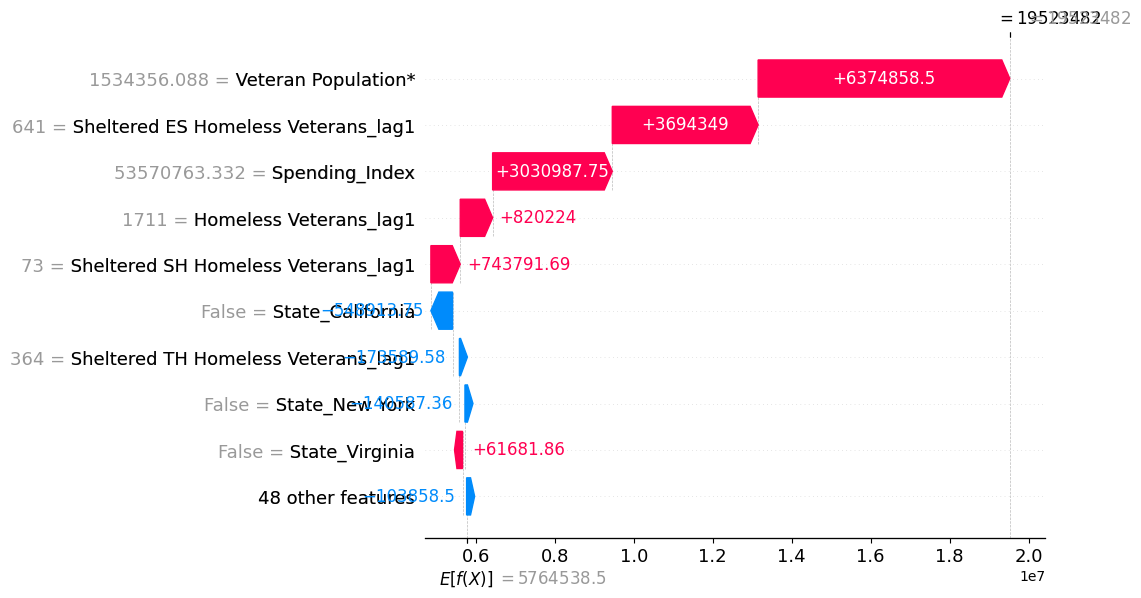

In [ ]:
#Texas
X_test_tx = X_test[X_test['State_Texas'] == 1]
X_test_tx_np = X_test_tx.to_numpy(dtype=float)

shap_values_tx = explainer.shap_values(X_test_tx_np)
i = 0  # or any index
# California
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_tx[i],
        base_values=explainer.expected_value,
        data=X_test_tx.iloc[i],
        feature_names=X_test.columns
    )
)

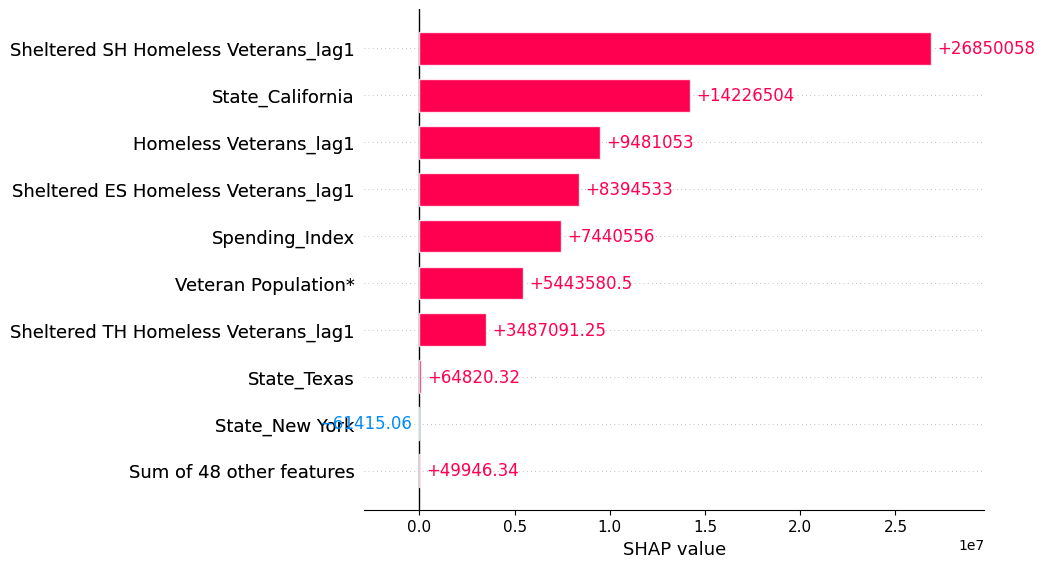

In [ ]:
import numpy as np

mean_shap_ca = np.mean(shap_values_ca, axis=0)

shap.plots.bar(
    shap.Explanation(
        values=mean_shap_ca,
        base_values=explainer.expected_value,
        feature_names=X_test.columns
    )
)

Just like the earlier XGBoost, this model improved drastically with the addition of 2 years and the manual imputation

2013-2015 R^2: 0.417
2013-2017 R^2: 0.937
2013-2023 R^2: 0.926
Once again, I am very skeptical, but I would be lying if I said the jump was exciting. Also, it being a lagged xgboost means it is more in line with our question. I will move onto to a baseline with Arima, and eventually PVAR

## 4.6 GMM Panel VAR (In Progress)

In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv("ssvf.csv")

In [ ]:

#Freaking Python doesnt have good Panel VAR Support
#However, R does so i can import some things over
# Install R
!apt-get install -y r-base

# Install rpy2 for Python-R interface
!pip install rpy2

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
r-base is already the newest version (4.5.3-1.2204.0).
0 upgraded, 0 newly installed, 0 to remove and 7 not upgraded.


In [ ]:
# Load rpy2 magic
%load_ext rpy2.ipython

In [ ]:
%%R
install.packages("panelvar", repos="https://cloud.r-project.org/")
library(panelvar)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/panelvar_0.5.6.tar.gz'
Content type 'application/x-gzip' length 1876300 bytes (1.8 MB)
downloaded 1.8 MB


The downloaded source packages are in
	‘/tmp/RtmpH86f0l/downloaded_packages’
Welcome to panelvar! Please cite our package in your publications -- see citation("panelvar")


In [ ]:
%%R
install.packages("plm", repos="https://cloud.r-project.org/")
install.packages("vars", repos="https://cloud.r-project.org/")
library(plm)
library(vars)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/plm_2.6-7.tar.gz'
Content type 'application/x-gzip' length 1370847 bytes (1.3 MB)
downloaded 1.3 MB


The downloaded source packages are in
	‘/tmp/RtmpH86f0l/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/vars_1.6-1.tar.gz'
Content type 'application/x-gzip' length 85590 bytes (83 KB)
downloaded 83 KB


The downloaded source packages are in
	‘/tmp/RtmpH86f0l/downloaded_packages’
Loading required package: MASS
Loading required package: strucchange
Loading required package: zoo

Attaching package: ‘zoo’

The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric

Loading required package: sandwich
Loading required package: urca
Loading required package: lmtest

Attaching package: ‘vars’

The following object is masked from ‘pa

In [ ]:
import pandas as pd

# Example: select relevant columns
df_r = df[['State','Year','ssvf_award_total','Homeless Veterans','Total Expenditure']]

# Ensure State and Year are strings or factors
df_r['State'] = df_r['State'].astype(str)
df_r['Year'] = df_r['Year'].astype(int)

/tmp/ipykernel_47439/3631054560.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_r['State'] = df_r['State'].astype(str)
/tmp/ipykernel_47439/3631054560.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_r['Year'] = df_r['Year'].astype(int)


In [ ]:
%R -i df_r

In [ ]:
%%R
str(df_r)

'data.frame':	564 obs. of  5 variables:
 $ State            : chr  "Alaska" "Arizona" "Arkansas" "California" ...
 $ Year             : int  2013 2013 2013 2013 2013 2013 2013 2013 2013 2013 ...
 $ ssvf_award_total : num  397879 2477610 495404 4760614 1989671 ...
 $ Homeless Veterans: int  210 1222 462 12895 685 341 89 499 5505 1805 ...
 $ Total Expenditure: num  501604 3220905 1946615 12707536 2594677 ...


In [ ]:
%%R
names(df_r)

[1] "State"             "Year"              "ssvf_award_total" 
[4] "Homeless Veterans" "Total Expenditure"


In [ ]:
%%R
table(table(df_r$State))


 3 11 
 1 51 


In [ ]:
%%R
colSums(is.na(df_r))

            State              Year  ssvf_award_total Homeless Veterans 
                0                 0                 0                 0 
Total Expenditure 
                0 


In [ ]:
%%R
library(panelvar)
library(plm)

# Clean column names
names(df_r) <- make.names(names(df_r))

# Fix types
df_r$State <- as.character(df_r$State)
df_r$Year <- as.numeric(df_r$Year)

df_r$ssvf_award_total <- as.numeric(df_r$ssvf_award_total)
df_r$Homeless.Veterans <- as.numeric(df_r$Homeless.Veterans)
df_r$Total.Expenditure <- as.numeric(df_r$Total.Expenditure)

In [ ]:
%%R
ls("package:panelvar")

 [1] "abdata"               "Andrews_Lu_MMSC"      "bootstrap_irf"       
 [4] "Cigar"                "Dahlberg"             "ex1_dahlberg_data"   
 [7] "ex1_dahlberg_data_bs" "ex2_nlswork2_data_bs" "ex3_abdata"          
[10] "extract"              "fevd_orthogonal"      "fixedeffects"        
[13] "girf"                 "hansen_j_test"        "nlswork2"            
[16] "oirf"                 "pvalue"               "pvarfeols"           
[19] "pvargmm"              "pvarhk"               "residuals_level"     
[22] "se"                   "stability"           


In [ ]:
%%R
library(dplyr)

df_r %>%
  group_by(State) %>%
  summarise(across(c(ssvf_award_total, Homeless.Veterans, Total.Expenditure),
                   ~ n_distinct(.))) %>%
  summary()

    State           ssvf_award_total Homeless.Veterans Total.Expenditure
 Length:52          Min.   : 1.000   Min.   : 3.00     Min.   : 3.00    
 Class :character   1st Qu.:10.000   1st Qu.:10.75     1st Qu.:11.00    
 Mode  :character   Median :11.000   Median :11.00     Median :11.00    
                    Mean   : 9.538   Mean   :10.52     Mean   :10.85    
                    3rd Qu.:11.000   3rd Qu.:11.00     3rd Qu.:11.00    
                    Max.   :11.000   Max.   :11.00     Max.   :11.00    


In [ ]:
#BASE LINE

%%R
pvar_model <- pvarfeols(
  dependent_vars = c("ssvf_award_total", "Homeless.Veterans", "Total.Expenditure"),
  lags = 1,
  data = df_r,
  panel_identifier = c("State", "Year")
)

summary(pvar_model)

---------------------------------------------------
Fixed Effects OLS Panel VAR estimation 
---------------------------------------------------
Transformation: demean 
Group variable: State 
Time variable: Year 
Number of observations = 564 
Number of groups = 52 
Obs per group: min = 3 
               avg = 10.84615 
               max = 11 

                                 demeaned_ssvf_award_total  demeaned_Homeless.Veterans  demeaned_Total.Expenditure
------------------------------------------------------------------------------------------------------------------
demeaned_lag1_ssvf_award_total      0.4841 ***              -0.0000 ***                   -0.0101                 
                                   (0.0357)                 (0.0000)                      (0.0056)                
demeaned_lag1_Homeless.Veterans  -701.6691 *                -0.0260                     -240.4530 ***             
                                 (336.4555)                 (0.0371)           

In [ ]:
%%R
install.packages("modelsummary")
library(modelsummary)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘bayestestR’, ‘datawizard’, ‘checkmate’, ‘insight’, ‘parameters’, ‘performance’, ‘tables’, ‘tinytable’

trying URL 'https://cran.rstudio.com/src/contrib/bayestestR_0.17.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/datawizard_1.3.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/checkmate_2.3.4.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/insight_1.4.6.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/parameters_0.28.3.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/performance_0.16.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/tables_0.9.33.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/tinytable_0.16.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/modelsummary_2.6.0.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpH86f0l/downloaded_packages’


In [ ]:
%%R
# Manually create a table for presentation
pvar_table <- data.frame(
  "Lagged Variable (t-1)" = c(
    "SSVF Award Total", "Homeless Veterans", "Total Expenditure"
  ),
  "SSVF Funding" = c("0.48 ***", "-701.67 *", "0.33 *"),
  "Veteran Homelessness" = c("0.00 ***", "-0.03", "0.00 *"),
  "Gov Spending" = c("-0.01", "-240.45 ***", "1.07 ***"),
  stringsAsFactors = FALSE
)

# Print as a table
pvar_table

  Lagged.Variable..t.1. SSVF.Funding Veteran.Homelessness Gov.Spending
1      SSVF Award Total     0.48 ***             0.00 ***        -0.01
2     Homeless Veterans    -701.67 *                -0.03  -240.45 ***
3     Total Expenditure       0.33 *               0.00 *     1.07 ***


In [ ]:
%%R
library(knitr)

kable(pvar_table, caption = "Panel VAR Results (Fixed Effects, Demeaned)")



Table: Panel VAR Results (Fixed Effects, Demeaned)

|Lagged.Variable..t.1. |SSVF.Funding |Veteran.Homelessness |Gov.Spending |
|:---------------------|:------------|:--------------------|:------------|
|SSVF Award Total      |0.48 ***     |0.00 ***             |-0.01        |
|Homeless Veterans     |-701.67 *    |-0.03                |-240.45 ***  |
|Total Expenditure     |0.33 *       |0.00 *               |1.07 ***     |


SOO, I got this model to work. YIPPEE!!
However, there is still a bit that needs to be fixed. These things are related to the table and constants within columns.

List of things to try:


*   Drop bad States
*   Drop bad Variables
*   Try using growth rates/ differences
    *   I have access to this stuff. It would just be time consuming to change everything



In [ ]:
%%R
library(dplyr)

df_filtered <- df_r %>%
  group_by(State) %>%
  filter(
    n_distinct(ssvf_award_total) > 1,
    n_distinct(Homeless.Veterans) > 1,
    n_distinct(Total.Expenditure) > 1

  ) %>%
  ungroup()

In [ ]:
#1st option
%%R
library(dplyr)

df_filtered <- as.data.frame(df_filtered)
df_filtered <- dplyr::ungroup(df_filtered)

In [ ]:
%%R
sapply(df_filtered, class)

            State              Year  ssvf_award_total Homeless.Veterans 
      "character"         "numeric"         "numeric"         "numeric" 
Total.Expenditure 
        "numeric" 


In [ ]:
%%R
df_filtered$State <- as.character(df_filtered$State)
df_filtered$Year <- as.numeric(df_filtered$Year)

df_filtered$ssvf_award_total <- as.numeric(df_filtered$ssvf_award_total)
df_filtered$Homeless.Veterans <- as.numeric(df_filtered$Homeless.Veterans)
df_filtered$Total.Expenditure <- as.numeric(df_filtered$Total.Expenditure)

In [ ]:
%%R
# Apply log transformation
# I know I needed to scale earlier, but I didn't apparently.
#Just doing this quickly here to check
# If have zeros (I dont for these) but then just add +1 like
# data$log_ssvf_award_total <- log(data$ssvf_award_total + 1)
df_filtered$log_ssvf_award_total <- log(df_filtered$ssvf_award_total)
df_filtered$log_Homeless.Veterans <- log(df_filtered$Homeless.Veterans)
df_filtered$log_Total.Expenditure <- log(df_filtered$Total.Expenditure)

In [ ]:
%%R
df_filtered <- df_filtered[order(df_filtered$State, df_filtered$Year), ]

In [ ]:
%%R
summary(df_filtered$log_ssvf_award_total)
summary(df_filtered$log_Homeless.Veterans)
summary(df_filtered$log_Total.Expenditure)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  11.10   14.16   14.85   14.77   15.37   17.14 


This is the model we are currently saying is the best

In [ ]:
# If log doesnt work, get rid of long in front of variables
%%R
pvar_model_l <- pvarfeols(

  dependent_vars = c("log_ssvf_award_total",
                    "log_Homeless.Veterans",
                    "log_Total.Expenditure"),
  lags = 1,
  data = df_filtered,
  panel_identifier = c("State", "Year")
)

summary(pvar_model)

---------------------------------------------------
Fixed Effects OLS Panel VAR estimation 
---------------------------------------------------
Transformation: demean 
Group variable: State 
Time variable: Year 
Number of observations = 564 
Number of groups = 52 
Obs per group: min = 3 
               avg = 10.84615 
               max = 11 

                                 demeaned_ssvf_award_total  demeaned_Homeless.Veterans  demeaned_Total.Expenditure
------------------------------------------------------------------------------------------------------------------
demeaned_lag1_ssvf_award_total      0.4841 ***              -0.0000 ***                   -0.0101                 
                                   (0.0357)                 (0.0000)                      (0.0056)                
demeaned_lag1_Homeless.Veterans  -701.6691 *                -0.0260                     -240.4530 ***             
                                 (336.4555)                 (0.0371)           

In [ ]:
# Manually create a clean table for presentation
%%R
pvar_log_table <- data.frame(
  "Lagged Variable (t-1)" = c(
    "SSVF Funding (log)",
    "Homeless Veterans (log)",
    "Total Expenditure (log)"
  ),
  "SSVF Funding (log)" = c("0.09 **", "-0.03", "0.32 ***"),
  "Veteran Homelessness (log)" = c("-0.04", "0.28 ***", "-0.62 ***"),
  "Gov Spending (log)" = c("-0.03 ***", "-0.07 ***", "0.95 ***"),
  stringsAsFactors = FALSE
)

# Print the table
pvar_log_table

# Optional: prettier version for slides
library(knitr)
kable(pvar_log_table, caption = "Panel VAR Results (Fixed Effects, Demeaned Logs)")



Table: Panel VAR Results (Fixed Effects, Demeaned Logs)

|Lagged.Variable..t.1.   |SSVF.Funding..log. |Veteran.Homelessness..log. |Gov.Spending..log. |
|:-----------------------|:------------------|:--------------------------|:------------------|
|SSVF Funding (log)      |0.09 **            |-0.04                      |-0.03 ***          |
|Homeless Veterans (log) |-0.03              |0.28 ***                   |-0.07 ***          |
|Total Expenditure (log) |0.32 ***           |-0.62 ***                  |0.95 ***           |


## Teesting variables for pvar

In [ ]:
import pandas as pd

# Example: select relevant columns
df_r_t = df[['State','Year','ssvf_award_total','Homeless Veterans','Medical Care']]

# Ensure State and Year are strings or factors
df_r_t['State'] = df_r_t['State'].astype(str)
df_r_t['Year'] = df_r_t['Year'].astype(int)

/tmp/ipykernel_47439/2497099073.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_r_t['State'] = df_r_t['State'].astype(str)
/tmp/ipykernel_47439/2497099073.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_r_t['Year'] = df_r_t['Year'].astype(int)


In [ ]:
%R -i df_r_t

In [ ]:
%%R
library(panelvar)
library(plm)

# Clean column names
names(df_r_t) <- make.names(names(df_r_t))

# Fix types
df_r_t$State <- as.character(df_r_t$State)
df_r_t$Year <- as.numeric(df_r_t$Year)

df_r_t$ssvf_award_total <- as.numeric(df_r_t$ssvf_award_total)
df_r_t$Homeless.Veterans <- as.numeric(df_r_t$Homeless.Veterans)
df_r_t$Medical.Care <- as.numeric(df_r_t$Medical.Care)

In [ ]:
%%R
library(dplyr)

df_filtered_t <- df_r_t %>%
  group_by(State) %>%
  filter(
    n_distinct(ssvf_award_total) > 1,
    n_distinct(Homeless.Veterans) > 1,
    n_distinct(Medical.Care) > 1 #Change this

  ) %>%
  ungroup()

In [ ]:
%%R
library(dplyr)

df_filtered_t <- as.data.frame(df_filtered_t)
df_filtered_t <- dplyr::ungroup(df_filtered_t)

In [ ]:
%%R
df_filtered_t$State <- as.character(df_filtered_t$State)
df_filtered_t$Year <- as.numeric(df_filtered_t$Year)

df_filtered_t$ssvf_award_total <- as.numeric(df_filtered_t$ssvf_award_total)
df_filtered_t$Homeless.Veterans <- as.numeric(df_filtered_t$Homeless.Veterans)
df_filtered_t$Medical.Care <- as.numeric(df_filtered_t$Medical.Care) #Change this

In [ ]:
%%R
# Apply log transformation
# I know I needed to scale earlier, but I didn't apparently.
#Just doing this quickly here to check
# If have zeros (I dont for these) but then just add +1 like
# data$log_ssvf_award_total <- log(data$ssvf_award_total + 1)
df_filtered_t$log_ssvf_award_total <- log(df_filtered_t$ssvf_award_total)
df_filtered_t$log_Homeless.Veterans <- log(df_filtered_t$Homeless.Veterans)
df_filtered_t$log_Medical.Care <- log(df_filtered_t$Medical.Care) #Change this

In [ ]:
%%R
df_filtered_t <- df_filtered_t[order(df_filtered_t$State, df_filtered_t$Year), ]

In [ ]:
%%R
summary(df_filtered_t$log_ssvf_award_total)
summary(df_filtered_t$log_Homeless.Veterans)
summary(df_filtered_t$log_Medical.Care) #Change this

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  9.106  13.301  13.951  13.834  14.424  16.080 


In [ ]:
#Testing out other variables
%%R
pvar_model_t <- pvarfeols(

  dependent_vars = c("log_ssvf_award_total",
                    "log_Homeless.Veterans",
                    "log_Medical.Care"), #Change this
  lags = 1,
  data = df_filtered_t,
  panel_identifier = c("State", "Year")
)

summary(pvar_model_t)

---------------------------------------------------
Fixed Effects OLS Panel VAR estimation 
---------------------------------------------------
Transformation: demean 
Group variable: State 
Time variable: Year 
Number of observations = 531 
Number of groups = 49 
Obs per group: min = 3 
               avg = 10.83673 
               max = 11 

                                     demeaned_log_ssvf_award_total  demeaned_log_Homeless.Veterans  demeaned_log_Medical.Care
-----------------------------------------------------------------------------------------------------------------------------
demeaned_lag1_log_ssvf_award_total    0.0927 **                     -0.0512                          0.0104                  
                                     (0.0294)                       (0.0299)                        (0.0089)                 
demeaned_lag1_log_Homeless.Veterans  -0.0393                         0.2820 ***                     -0.0925 ***              
                        

In [ ]:
# Manually create a clean table for presentation
%%R
pvar_log_table <- data.frame(
  "Lagged Variable (t-1)" = c(
    "SSVF Funding (log)",
    "Homeless Veterans (log)",
    "Total Expenditure (log)"
  ),
  "SSVF Funding (log)" = c("0.09 **", "-0.04", "0. 0.25***"),
  "Veteran Homelessness (log)" = c("-0.05", "0.28 ***", "-0.62 ***"),
  "Gov Spending (log)" = c("0.01", "-0.09 ***", "0.85 ***"),
  stringsAsFactors = FALSE
)

# Print the table
pvar_log_table

# Optional: prettier version for slides
library(knitr)
kable(pvar_log_table, caption = "Panel VAR Results (Fixed Effects, Demeaned Logs)")



Table: Panel VAR Results (Fixed Effects, Demeaned Logs)

|Lagged.Variable..t.1.   |SSVF.Funding..log. |Veteran.Homelessness..log. |Gov.Spending..log. |
|:-----------------------|:------------------|:--------------------------|:------------------|
|SSVF Funding (log)      |0.09 **            |-0.05                      |0.01               |
|Homeless Veterans (log) |-0.04              |0.28 ***                   |-0.09 ***          |
|Total Expenditure (log) |0. 0.25***         |-0.62 ***                  |0.85 ***           |


## Running IRF

In addition: Warning message:
`aes_()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`
ℹ The deprecated feature was likely used in the panelvar package.
  Please report the issue to the authors.
This warning is displayed once per session.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


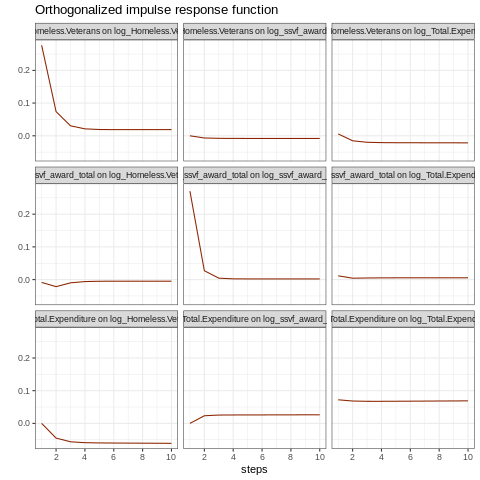

In [ ]:
#PVAR is technically a whitebox model, and IRF's are used to help interpret the coefficents
# However, the pnalevar package has multiple types of IRF
# Orthogonal IRF
# Generalized IRF
# Bootstrap
# Imma use all of them, then determinethebest one to use

#Orthogonal
%%R

irf_model_o <- oirf(
  pvar_model,
  n.ahead = 10
)

plot(irf_model_o)

In [ ]:
#This is what I need to interpret, it is interpretable from here
# but I want to clean it up for my understanding
%%R

str(irf_model_o)

List of 3
 $ log_ssvf_award_total : num [1:10, 1:3] 0.27032 0.02711 0.00436 0.00227 0.00209 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : NULL
  .. ..$ : chr [1:3] "log_ssvf_award_total" "log_Homeless.Veterans" "log_Total.Expenditure"
 $ log_Homeless.Veterans: num [1:10, 1:3] 0 -0.00663 -0.00776 -0.008 -0.00807 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : NULL
  .. ..$ : chr [1:3] "log_ssvf_award_total" "log_Homeless.Veterans" "log_Total.Expenditure"
 $ log_Total.Expenditure: num [1:10, 1:3] 0 0.0233 0.0255 0.0257 0.0258 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : NULL
  .. ..$ : chr [1:3] "log_ssvf_award_total" "log_Homeless.Veterans" "log_Total.Expenditure"
 - attr(*, "class")= chr "pvarfeolsoirf"


In [ ]:
%%R
library(reshape2)

irf_list <- irf_model_o

# Convert each matrix to a data frame
irf_df <- do.call(rbind, lapply(names(irf_list), function(shock) {

  df <- as.data.frame(irf_list[[shock]])
  df$Horizon <- 1:nrow(df)
  df$Shock <- shock

  return(df)
}))

# Melt into long format
irf_long <- melt(irf_df, id.vars = c("Horizon", "Shock"),
                 variable.name = "Response",
                 value.name = "IRF")

irf_long

   Horizon                 Shock              Response          IRF
1        1  log_ssvf_award_total  log_ssvf_award_total  0.270315386
2        2  log_ssvf_award_total  log_ssvf_award_total  0.027110072
3        3  log_ssvf_award_total  log_ssvf_award_total  0.004358972
4        4  log_ssvf_award_total  log_ssvf_award_total  0.002267337
5        5  log_ssvf_award_total  log_ssvf_award_total  0.002087738
6        6  log_ssvf_award_total  log_ssvf_award_total  0.002079892
7        7  log_ssvf_award_total  log_ssvf_award_total  0.002086344
8        8  log_ssvf_award_total  log_ssvf_award_total  0.002093748
9        9  log_ssvf_award_total  log_ssvf_award_total  0.002101174
10      10  log_ssvf_award_total  log_ssvf_award_total  0.002108606
11       1 log_Homeless.Veterans  log_ssvf_award_total  0.000000000
12       2 log_Homeless.Veterans  log_ssvf_award_total -0.006634915
13       3 log_Homeless.Veterans  log_ssvf_award_total -0.007763020
14       4 log_Homeless.Veterans  log_ssvf_award

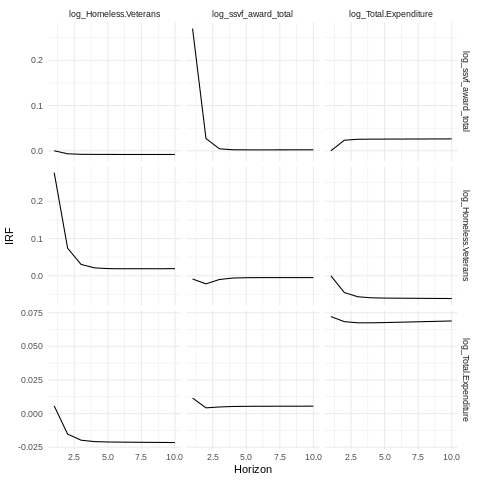

In [ ]:
%%R
library(ggplot2)

ggplot(irf_long, aes(x = Horizon, y = IRF)) +
  geom_line() +
  facet_grid(Response ~ Shock, scales = "free_y") +
  theme_minimal()

#Testing IRFs

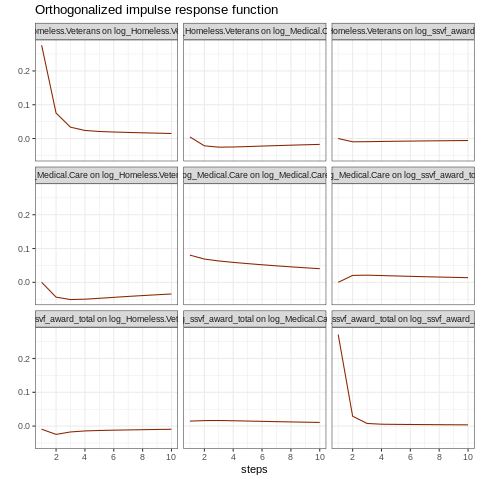

In [ ]:
%%R

irf_model_t <- oirf(
  pvar_model_t,
  n.ahead = 10
)

plot(irf_model_t)

In [ ]:
%%R
library(reshape2)

irf_list_t <- irf_model_t

# Convert each matrix to a data frame
irf_df_t <- do.call(rbind, lapply(names(irf_list_t), function(shock) {

  df_t <- as.data.frame(irf_list_t[[shock]])
  df_t$Horizon <- 1:nrow(df_t)
  df_t$Shock <- shock

  return(df_t)
}))

# Melt into long format
irf_long_t <- melt(irf_df_t, id.vars = c("Horizon", "Shock"),
                 variable.name = "Response",
                 value.name = "IRF")

irf_long

   Horizon                 Shock              Response          IRF
1        1  log_ssvf_award_total  log_ssvf_award_total  0.270315386
2        2  log_ssvf_award_total  log_ssvf_award_total  0.027110072
3        3  log_ssvf_award_total  log_ssvf_award_total  0.004358972
4        4  log_ssvf_award_total  log_ssvf_award_total  0.002267337
5        5  log_ssvf_award_total  log_ssvf_award_total  0.002087738
6        6  log_ssvf_award_total  log_ssvf_award_total  0.002079892
7        7  log_ssvf_award_total  log_ssvf_award_total  0.002086344
8        8  log_ssvf_award_total  log_ssvf_award_total  0.002093748
9        9  log_ssvf_award_total  log_ssvf_award_total  0.002101174
10      10  log_ssvf_award_total  log_ssvf_award_total  0.002108606
11       1 log_Homeless.Veterans  log_ssvf_award_total  0.000000000
12       2 log_Homeless.Veterans  log_ssvf_award_total -0.006634915
13       3 log_Homeless.Veterans  log_ssvf_award_total -0.007763020
14       4 log_Homeless.Veterans  log_ssvf_award